In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#***Analyzing the Purchase Data of All Invoices***

###**1. Load the dataset - All invoices _ Purchase Data**: Find the count of missing data on each column

In [ ]:
#load the purchases dataset
import pandas as pd
purchase_df = pd.read_csv('/content/drive/My Drive/Final Capstone BAAI-16/Procurement_Saahas/Purchase Data_VMS.csv')
#purchases.info()
#print total count of rows
print(f"Total number of data rows: {purchase_df.shape[0]}")
print('--------------------------------------------------------------------------------------------')
#
print(purchase_df.isnull().sum())
print('--------------------------------------------------------------------------------------------')
#

print(purchase_df.columns)

Total number of data rows: 23872
--------------------------------------------------------------------------------------------
ID                                                       0
Vendor Code                                           1163
Vendor Name                                             37
Business Vertical                                    17230
Submission Date                                          1
Invoice Status                                       17257
Booking status (For Accounts only)                    7394
Payment Type                                         14041
Document Type                                        13157
Division                                              5609
Business Group                                       17230
Branch                                               15932
Vendor Email                                           128
Invoice Date                                             0
Invoice #                                       

/tmp/ipykernel_2927/195904892.py:3: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  purchase_df = pd.read_csv('/content/drive/My Drive/Final Capstone BAAI-16/Procurement_Saahas/Purchase Data_VMS.csv')


In [ ]:
# Vendor Name standardization
#purchase_df['Vendor Name'] = purchase_df['Vendor Name'].str.upper()

In [ ]:
# drop columns applicability and paid amount
#purchase_df.drop(['Applicability?'], axis=1, inplace=True)
#print(purchase_df.columns)

##**2.** Fill empty Business Vertical values with Division column values and check the empty value count on **Business Vertical**

In [ ]:
#Code to fill empty Business Vertical values with Division column values
purchase_df['Business Vertical'].fillna(purchase_df['Division'], inplace=True)
#print the null count on Business Vertical
print(purchase_df['Business Vertical'].isnull().sum())
#
#
print(purchase_df.isnull().sum())
#

/tmp/ipykernel_2927/2535626798.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  purchase_df['Business Vertical'].fillna(purchase_df['Division'], inplace=True)


0
ID                                                       0
Vendor Code                                           1163
Vendor Name                                             37
Business Vertical                                        0
Submission Date                                          1
Invoice Status                                       17257
Booking status (For Accounts only)                    7394
Payment Type                                         14041
Document Type                                        13157
Division                                              5609
Business Group                                       17230
Branch                                               15932
Vendor Email                                           128
Invoice Date                                             0
Invoice #                                                7
Details                                                  0
Expense Type                                          

##**3.** List the different Business Verticals

In [ ]:
# Print the values in Business Vertical
print(purchase_df['Business Vertical'].unique())

['Plastic Operations' 'Circular Textiles' 'MRF GOA' 'MRF Bengaluru'
 'ZWP Operations' 'Products' 'Ewaste' 'Sarvam' 'SEP Sarvam' 'MRF Gurugram'
 'Admin' 'Refurbishment' 'SEP PCB' 'ZWP Sales' 'MRF Consulting' 'IT'
 'PRF Jigni' 'Social Inclusion' 'PRF Job Work' 'QEHS' 'Marketing'
 'General' 'Sarvam MRF' 'Strategic Projects' 'Consulting' 'CT/TRF' 'EPR'
 'EWaste' 'MRF' 'PRF' 'Tyre' 'ZWP' 'ZWP-Sales']


##**4.** Impute the EPR Business Vertical with Plastic Operations **(as renamed now by SZW)**

In [ ]:
#If Business Vertical is EPR replace that with Plastics Operations
purchase_df.loc[purchase_df['Business Vertical'] == 'EPR', 'Business Vertical'] = 'Plastic Operations'

In [ ]:

# if Business Vertical name is Admin, IT, Social Inclusion, PRF Job Work, QEHS, Marketing, General drop the rows
purchase_df = purchase_df[~purchase_df['Business Vertical'].isin(['Admin', 'IT', 'Social Inclusion', 'PRF Job Work', 'QEHS', 'Marketing', 'General'])]
print(purchase_df['Business Vertical'].unique())

['Plastic Operations' 'Circular Textiles' 'MRF GOA' 'MRF Bengaluru'
 'ZWP Operations' 'Products' 'Ewaste' 'Sarvam' 'SEP Sarvam' 'MRF Gurugram'
 'Refurbishment' 'SEP PCB' 'ZWP Sales' 'MRF Consulting' 'PRF Jigni'
 'Sarvam MRF' 'Strategic Projects' 'Consulting' 'CT/TRF' 'EWaste' 'MRF'
 'PRF' 'Tyre' 'ZWP' 'ZWP-Sales']


##**5.** Impute ZWP-Sales with ZWP Sales as they are same

In [ ]:
# Impute ZWP-Sales with ZWP Sales as they are same
purchase_df.loc[purchase_df['Business Vertical'] == 'ZWP-Sales', 'Business Vertical'] = 'ZWP Sales'

##**6.** Get the appropriate name for the 'Ewaste' in Business Vertical so as to group them for requirements

In [ ]:
#If Business Vertical is EWaste or Refurbishment replace that with Ewaste
#purchase_vms.loc[purchase_vms['Business Vertical'] == 'EWaste', 'Business Vertical'] = 'Ewaste'
#purchase_vms.loc[purchase_vms['Business Vertical'] == 'Refurbishment', 'Business Vertical'] = 'Ewaste'
#print the count of rows with Business Vertical equal to Ewaste
#print(purchase_vms[purchase_vms['Business Vertical'] == 'Ewaste'].shape[0])
#

In [ ]:

!pip install thefuzz
from thefuzz import process

def standardize_ewaste(val):
    if pd.isna(val): return val
    # Extract the similarity score against the word "Ewaste"
    # match[0] is the string, match[1] is the score (0-100)
    match = process.extractOne(val, ["Ewaste"])

    if match[1] > 80:  # If it's 80% similar or more, rename it
        return "Ewaste"
    return val

purchase_df['Business Vertical'] = purchase_df['Business Vertical'].apply(standardize_ewaste)
print(purchase_df[purchase_df['Business Vertical'] == 'Ewaste'].shape[0])

5033


##**7.** Drop the irrelevant columns

In [ ]:
#drop the columns Business Group and Division
#purchase_df.drop(['ID','Modified User','Business Group', 'Division','Vendor Email','Added User','Modified Time'],
 #                 axis=1, inplace=True, errors='ignore')
#purchase_df.info()

In [ ]:
#Find the correlation coefficients among all amount factors
#print(purchase_vms[['Sum of Base Amount', ' Sum of Tax Amount', 'Sum of Total Amount']].corr())
#drop the columns if corr > 0.9
#purchase_vms.drop(['Sum of Base Amount', ' Sum of Tax Amount'], axis=1, inplace=True)

In [ ]:
print(purchase_df.isnull().sum())

ID                                                       0
Vendor Code                                           1150
Vendor Name                                             37
Business Vertical                                        0
Submission Date                                          1
Invoice Status                                       17207
Booking status (For Accounts only)                    7296
Payment Type                                         14006
Document Type                                        13131
Division                                              5514
Business Group                                       17180
Branch                                               15872
Vendor Email                                           122
Invoice Date                                             0
Invoice #                                                7
Details                                                  0
Expense Type                                          22

##**9.** Drop all data rows with **Empty** Vendor Names

In [ ]:
# drop all rows with null vendor names
purchase_df = purchase_df.dropna(subset=['Vendor Name'])
print(purchase_df.isnull().sum())
#

ID                                                       0
Vendor Code                                           1118
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          1
Invoice Status                                       17196
Booking status (For Accounts only)                    7287
Payment Type                                         14006
Document Type                                        13129
Division                                              5492
Business Group                                       17169
Branch                                               15864
Vendor Email                                           107
Invoice Date                                             0
Invoice #                                                7
Details                                                  0
Expense Type                                          22

##**10a.** Find the count of values in **Invoice Status**

In [ ]:
#find the value counts in Invoice Status
print(purchase_df['Invoice Status'].value_counts())
#find the empty values of Invoive status
print('-----------------------------------------------------------------------')
print(purchase_df['Invoice Status'].isnull().sum())
#

Invoice Status
Full Paid Invoices               5177
Part Paid Invoices                435
Rejected Invoices                 272
Finance Crosschecked Invoices     252
Lead Approved Invoices            111
Pending Invoices                   36
Approved by Finance Invoices       36
Crosschecked Invoices               2
Name: count, dtype: int64
-----------------------------------------------------------------------
17196


##**10b.Impute** the null values of Invoices Status with **Rejected Invoices** if values exist in Rejection comments

In [ ]:
#Display the Rejection Comments
#print(purchase_vms['Rejection Comments'].unique())
#print the total count of non-null rejection comments
print('-------------------------------------------------------------------------------')
print(purchase_df['Rejection Comments'].notnull().sum())
print('-------------------------------------------------------------------------------')
#print count of those rows where both rejection comments and Invoice status are not null and the Invoice status is Rejected Invoices
#print(purchase_vms[(purchase_vms['Rejection Comments'].notnull()) & (purchase_vms['Invoice Status'].notnull()==True)
#& (purchase_vms['Invoice Status'] == 'Rejected Invoices')].shape[0])

#if Invoice Status is null and rejection comments is not null, impute Invoice statuts with Rejected Invoices
purchase_df.loc[purchase_df['Rejection Comments'].notnull(), 'Invoice Status'] = 'Rejected Invoices'

print('-------------------------------------------------------------------------------')
print(purchase_df['Invoice Status'].value_counts())
print('-------------------------------------------------------------------------------')
print(purchase_df['Invoice Status'].isnull().sum())

#

-------------------------------------------------------------------------------
623
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
Invoice Status
Full Paid Invoices               5177
Rejected Invoices                 886
Part Paid Invoices                435
Finance Crosschecked Invoices     252
Lead Approved Invoices            111
Pending Invoices                   36
Approved by Finance Invoices       36
Crosschecked Invoices               2
Name: count, dtype: int64
-------------------------------------------------------------------------------
16582


 ## **11.** In case of empty Invoice status but there is a payment Date or the Booking Status is **Booked**, **impute** these cells as **Fully Paid Invoices**

In [ ]:
#if Payment Date is not null or Booking Status is 'Booked' but Invoice Status is null, impute the cells with value Fully Paid Invoices

purchase_df.loc[((purchase_df['Payment Date'].notnull())|(purchase_df['Booking status (For Accounts only)'] == 'Booked')) & (purchase_df['Invoice Status'].isnull()), 'Invoice Status'] = 'Full Paid Invoices'

print("Value counts of Invoice Status after imputation:")
print(purchase_df['Invoice Status'].value_counts())

print("\nNull values in Invoice Status after imputation:")
print(purchase_df['Invoice Status'].isnull().sum())


Value counts of Invoice Status after imputation:
Invoice Status
Full Paid Invoices               20787
Rejected Invoices                  886
Part Paid Invoices                 435
Finance Crosschecked Invoices      252
Lead Approved Invoices             111
Pending Invoices                    36
Approved by Finance Invoices        36
Crosschecked Invoices                2
Name: count, dtype: int64

Null values in Invoice Status after imputation:
972


##**12.** For Balance = NULL|0, impute Invoice Status  = Full Paid Invoices

In [ ]:
# if Balance column value is 0 or null and Invoice ststus is null, fill Invoice status as Full Paid Invoices
purchase_df.loc[((purchase_df['Balance'] == 0) | (purchase_df['Balance'].isnull())) & (purchase_df['Invoice Status'].isnull()), 'Invoice Status'] = 'Full Paid Invoices'
print("Value counts of Invoice Status after imputation:")
print(purchase_df['Invoice Status'].value_counts())


Value counts of Invoice Status after imputation:
Invoice Status
Full Paid Invoices               21759
Rejected Invoices                  886
Part Paid Invoices                 435
Finance Crosschecked Invoices      252
Lead Approved Invoices             111
Pending Invoices                    36
Approved by Finance Invoices        36
Crosschecked Invoices                2
Name: count, dtype: int64


In [ ]:

# for the business verticals SEP PCB, Tyre, Consulting, Sarvam MRF, Strtategic Projects, PRF, print Invoice Status null value counts
df = purchase_df
verticals = df['Business Vertical'] # Corrected column name from 'Business Verticals' to 'Business Vertical'

# Filter required business verticals
filtered_df = df[df['Business Vertical'].isin(verticals)]

# Count null Invoice Status per Business Vertical
null_counts = (
    filtered_df
    .groupby('Business Vertical')['Invoice Status']
    .apply(lambda x: x.isna().sum())
)

print(null_counts)

#print sum of null counts
print(null_counts.sum())


Business Vertical
CT/TRF                0
Circular Textiles     0
Consulting            0
Ewaste                0
MRF                   0
MRF Bengaluru         0
MRF Consulting        0
MRF GOA               0
MRF Gurugram          0
PRF                   0
PRF Jigni             0
Plastic Operations    0
Products              0
Refurbishment         0
SEP PCB               0
SEP Sarvam            0
Sarvam                0
Sarvam MRF            0
Strategic Projects    0
Tyre                  0
ZWP                   0
ZWP Operations        0
ZWP Sales             0
Name: Invoice Status, dtype: int64
0


In [ ]:
# Calculate percentage of missing dta in total amount
missing_percentage = (purchase_df['Invoice Status'].isnull().sum() / purchase_df.shape[0]) *100
print(f"Missing percentage of Invoice Status: {missing_percentage:.2f}%")

Missing percentage of Invoice Status: 0.00%


In [ ]:
# drop the missing invoices
#purchase_df = purchase_df.dropna(subset=['Invoice Status'])

In [ ]:
# print dataframe null values
print(purchase_df.isnull().sum())
#

ID                                                       0
Vendor Code                                           1118
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          1
Invoice Status                                           0
Booking status (For Accounts only)                    7287
Payment Type                                         14006
Document Type                                        13129
Division                                              5492
Business Group                                       17169
Branch                                               15864
Vendor Email                                           107
Invoice Date                                             0
Invoice #                                                7
Details                                                  0
Expense Type                                          22

In [ ]:
# Drop irrelevant columns
purchase_df.drop(['Finance Comments', 'Rejection Comments', 'Debit Note','Credit Note','Balance','Approved date by Lead',
                  'Payment Type', 'Document Type', 'Payment Due on', 'Payment Date','Any Special Requets', 'Transaction No'], axis=1, inplace=True)
print(purchase_df.columns)
#

Index(['ID', 'Vendor Code', 'Vendor Name', 'Business Vertical',
       'Submission Date', 'Invoice Status',
       'Booking status (For Accounts only)', 'Division', 'Business Group',
       'Branch', 'Vendor Email', 'Invoice Date', 'Invoice #', 'Details',
       'Expense Type', 'Invoice Softcopy', 'Applicability?', 'TDS Deduction',
       'Modified User', 'For the Month of (Month when services were given)',
       'Sum of Base Amount', ' Sum of Tax Amount', 'Sum of Total Amount',
       'Paid Amount', 'Added User', 'Modified Time'],
      dtype='object')


In [ ]:
# print isnull
print(purchase_df.isnull().sum())
# print total data points
print(f"Total number of data rows: {purchase_df.shape[0]}")

ID                                                       0
Vendor Code                                           1118
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          1
Invoice Status                                           0
Booking status (For Accounts only)                    7287
Division                                              5492
Business Group                                       17169
Branch                                               15864
Vendor Email                                           107
Invoice Date                                             0
Invoice #                                                7
Details                                                  0
Expense Type                                          2289
Invoice Softcopy                                         0
Applicability?                                       229

## **13.** Reorder Details column for data transformation

In [ ]:
## 2. Identify the 'Details' column and create the new column order
column_to_move = 'Details'

#remove the column from the current position
cols = list(purchase_df.columns)
cols.remove(column_to_move)

#append this col to the end of the list
cols.append(column_to_move)

#print reodered dataframe
df_reordered = purchase_df[cols].copy()
print(df_reordered.columns)
print(df_reordered.shape)
#

Index(['ID', 'Vendor Code', 'Vendor Name', 'Business Vertical',
       'Submission Date', 'Invoice Status',
       'Booking status (For Accounts only)', 'Division', 'Business Group',
       'Branch', 'Vendor Email', 'Invoice Date', 'Invoice #', 'Expense Type',
       'Invoice Softcopy', 'Applicability?', 'TDS Deduction', 'Modified User',
       'For the Month of (Month when services were given)',
       'Sum of Base Amount', ' Sum of Tax Amount', 'Sum of Total Amount',
       'Paid Amount', 'Added User', 'Modified Time', 'Details'],
      dtype='object')
(23517, 26)


In [ ]:
# print into output csv
#df_reordered.to_csv('/content/Purchase Data_VMS_item.csv', index=False)

## **14.** Replace Item Names with proper names removing special characters

In [ ]:
# load item details look up
item_details_lookup_df = pd.read_csv('/content/drive/My Drive/Final Capstone BAAI-16/Procurement_Saahas/replacement_items_lookup.csv')
print(f"Total number of data rows: {item_details_lookup_df.shape[0]}")

Total number of data rows: 11


In [ ]:
print(item_details_lookup_df.columns)

Index(['Original', 'Refined'], dtype='object')


In [ ]:
# for each item name in lookup_df, if details column values match with details column values in df_reoredered,
# replace details in df_reordered with item name from lookupdf
for index, row in item_details_lookup_df.iterrows():
  item_name = row['Refined']
  df_reordered.loc[df_reordered['Details'] == row['Original'], 'Details'] = item_name

In [ ]:
#copy df reoredered to output file
#df_reordered.to_csv('/content/Purchase Data_VMS_item_after.csv', index=False)
#

In [ ]:
#df_reordered['Details'] = df_reordered['Details'].map(item_details_lookup_df.set_index('Details')['Item Name'].fillna(df_reordered['Details']))

In [ ]:
print(df_reordered.shape)

(23517, 26)


## **15.** Split the Details column to get the **Item Name, Quantity and Rate per kg**

In [ ]:
#if the entry is Item name-rate per kg-quantity- total amount, split into Item Name, Rate per kg, Quantity and truncate the total amount

import re

#If Details contains string FY 20-21 replace with FY 20_21
df_reordered['Details'] = df_reordered['Details'].str.replace('FY 20-21', 'FY 20_21')

# 1️. Split rows wherever Details contains commas
df_reordered = df_reordered.assign(Details=df_reordered['Details'].str.split(',')) \
       .explode('Details')

df_reordered['Details'] = df_reordered['Details'].str.strip()

# Handle potential NaN values by converting them to empty strings before applying regex split
df_reordered['Details'] = df_reordered['Details'].fillna('')

# 2️. Split using '-' ONLY when dash is followed by a number
# Pattern: split on '-' only if next char is a digit
def smart_split(s):
    # Split only on "-" that precedes a digit
    parts = re.split(r'-(?=\d)', s)
    return parts

# Apply custom split
split_cols = df_reordered['Details'].apply(lambda x: pd.Series(smart_split(x)))

# Name dynamic columns
split_cols.columns = [f"Part{i+1}" for i in range(split_cols.shape[1])]

# Final dataframe
df_final = pd.concat([df_reordered, split_cols], axis=1)

#print(df_final)

#rename Part 1 to Item Name, Part 2 to Rate per quantity, Part 3 to Quantity and Part 4 to Total Amount
df_final = df_final.rename(columns={'Part1': 'Item Name',
                                    'Part2': 'Rate per kg',
                                    'Part3': 'Quantity',
                                    'Part4': 'Total Amount'})
print(df_final.columns)
print(df_final.shape)
#

Index(['ID', 'Vendor Code', 'Vendor Name', 'Business Vertical',
       'Submission Date', 'Invoice Status',
       'Booking status (For Accounts only)', 'Division', 'Business Group',
       'Branch', 'Vendor Email', 'Invoice Date', 'Invoice #', 'Expense Type',
       'Invoice Softcopy', 'Applicability?', 'TDS Deduction', 'Modified User',
       'For the Month of (Month when services were given)',
       'Sum of Base Amount', ' Sum of Tax Amount', 'Sum of Total Amount',
       'Paid Amount', 'Added User', 'Modified Time', 'Details', 'Item Name',
       'Rate per kg', 'Quantity', 'Total Amount'],
      dtype='object')
(32697, 30)


In [ ]:
# copy df final to output file
df_final.to_csv('/content/Purchase Data_VMS_item_updated.csv', index=False)
#

## **16.** Look up for items matching to in **look up items** list if any, move those rows (make Business Vertical because they are now moved to **Refurbishment** vertical- as stated by SZW

In [ ]:
# Load updated dataset
df_updated = pd.read_csv('/content/Purchase Data_VMS_item_updated.csv')

In [ ]:
#Look up for items matching to in **look up items** list if any
look_up_items = ['/content/drive/My Drive/Final Capstone BAAI-16/Procurement_Saahas/Lookup_items.csv']
for file in look_up_items:
  df_lookup = pd.read_csv(file)
  print(f"Total number of data rows in: {df_lookup.shape[0]}")

Total number of data rows in: 190


In [ ]:
#if Vendor Name and Item Name in df_updated match with Vendor Name and Item_Name in df_lookup, replace Business Vertcal 'Ewaste' with 'Refurbishment'
for index, row in df_updated.iterrows():
  vendor_name = row['Vendor Name']
  item_name = row['Item Name']

  if df_lookup[(df_lookup['Vendor Name'] == vendor_name) & (df_lookup['Item_Name'] == item_name)].shape[0] > 0:
    df_updated.at[index, 'Business Vertical'] = 'Refurbishment'

print(df_updated['Business Vertical'].value_counts())
#

Business Vertical
Plastic Operations    9278
Ewaste                5289
MRF                   5110
ZWP                   3232
ZWP Operations        2363
Products              1832
MRF Bengaluru         1643
SEP Sarvam             714
Refurbishment          644
Sarvam                 604
MRF GOA                539
MRF Gurugram           421
Circular Textiles      279
ZWP Sales              248
PRF Jigni              227
MRF Consulting         125
CT/TRF                  80
SEP PCB                 29
Tyre                    12
Consulting              10
PRF                      9
Sarvam MRF               6
Strategic Projects       3
Name: count, dtype: int64


In [ ]:
# print total data points count
print(f"Total number of data rows: {df_updated.shape}")
#

Total number of data rows: (32697, 30)


## **17.** Remove the empty vendor name rows

In [ ]:
#Load updated dataset
df_updated = pd.read_csv('/content/Purchase Data_VMS_item_updated.csv')
print(df_updated.isnull().sum())
print(df_updated.shape)

#drop rows with empty vendor names and Item Name
df_updated = df_updated.dropna(subset=['Vendor Name', 'Item Name', 'Submission Date'])
print(df_updated.isnull().sum())
print(df_updated.shape)


ID                                                       0
Vendor Code                                           1611
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          1
Invoice Status                                           0
Booking status (For Accounts only)                   10104
Division                                              8534
Business Group                                       22966
Branch                                               21889
Vendor Email                                           131
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3425
Invoice Softcopy                                         0
Applicability?                                       31861
TDS Deduction                                          1

## **17.1** Drop Vendor Code

In [ ]:
#remove vendor code column
df_updated.drop(['Vendor Code'], axis=1, inplace=True)
print(df_updated.columns)

Index(['ID', 'Vendor Name', 'Business Vertical', 'Submission Date',
       'Invoice Status', 'Booking status (For Accounts only)', 'Division',
       'Business Group', 'Branch', 'Vendor Email', 'Invoice Date', 'Invoice #',
       'Expense Type', 'Invoice Softcopy', 'Applicability?', 'TDS Deduction',
       'Modified User', 'For the Month of (Month when services were given)',
       'Sum of Base Amount', ' Sum of Tax Amount', 'Sum of Total Amount',
       'Paid Amount', 'Added User', 'Modified Time', 'Details', 'Item Name',
       'Rate per kg', 'Quantity', 'Total Amount'],
      dtype='object')


## **18.** Impute Empty Total AMount values with available Sum of Base Amount values

In [ ]:
# if details value = item name then,
# fill Total Amount = Sum of Base Amount if Sum of Base AMount is not null and Total AMount is null or 0

# Combine all conditions into a single boolean mask for df.loc
condition = (
    (df_updated['Details'] == df_updated['Item Name']) &
    (df_updated['Sum of Base Amount'].notnull()) &
    (df_updated['Total Amount'].isnull() | (df_updated['Total Amount'] == 0))
)
df_updated.loc[condition, 'Total Amount'] = df_updated['Sum of Base Amount']

print(df_updated.isnull().sum())
#

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                   10104
Division                                              8533
Business Group                                       22965
Branch                                               21888
Vendor Email                                           131
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3425
Invoice Softcopy                                         0
Applicability?                                       31859
TDS Deduction                                          112
Modified User                                           

In [ ]:
print(df_updated.shape)

(32695, 29)


In [ ]:
#copy df to output
df_updated.to_csv('/content/Purchase Data_Updated.csv', index=False)
#

In [ ]:
# print all values where Rate per kg is null
#print(df_updated[df_updated['Rate per kg'].isnull()].head)
#

## **19.** Check for Rate per kg = 0

In [ ]:
# print the count of Rate per kg values = 0
print(df_updated[df_updated['Rate per kg'] == 0].shape[0])

194


## **20.** SInce, it is within the MRF, so Rate per kg and Total AMount can be 0, hence, impute accordingly

In [ ]:
# if Business verticals = MRF drop the rows whose Rate per kg =0
#df_updated.drop(df_updated[(df_updated['Business Vertical'] == 'MRF') & (df_updated['Rate per kg'] == 0) & df_updated['Total Amount'] == 0].index, inplace=True)
#print(df_updated[df_updated['Rate per kg'] == 0].shape[0])
#print(df_updated[df_updated['Quantity'] == 0].shape[0])

In [ ]:
df_updated = df_updated[
    ~(
        (df_updated['Business Vertical'].isin(['MRF'])) &
        (df_updated['Invoice Status'] == 'Full Paid Invoices') &
        (df_updated['Rate per kg'] == 0) &
        (df_updated['Total Amount'] == 0)
    )
]

In [ ]:
# copy into output
#df_updated.to_csv('/content/Purchase Data_Updated.csv', index=False)
#

In [ ]:
print(df_updated.shape)

(32542, 29)


## **21.** Business call - The waste was procured for zero cost because this vendor **Shri Muneswara Swami Prasanna** has couple of Rejected Invoices against their name

In [ ]:
df_updated = df_updated[
    ~(
        (df_updated['Vendor Name'] == 'Shri Muneswara Swami Prasanna') &
        (df_updated['Invoice Status'] == 'Full Paid Invoices') &
        (df_updated['Rate per kg'] == 0) &
        (df_updated['Total Amount'] == 0)
    )
]

In [ ]:
print(df_updated.shape)

(32524, 29)


In [ ]:
# copy to output file
df_updated.to_csv('/content/Purchase Data_Updated.csv', index=False)
#

##**21.1.** If Rate per kg still empty, impute it as Total Amount/ Quantity

In [ ]:
# Convert columns to numeric, coercing errors to NaN
df_updated['Total Amount'] = pd.to_numeric(df_updated['Total Amount'], errors='coerce')
df_updated['Quantity'] = pd.to_numeric(df_updated['Quantity'], errors='coerce')
df_updated['Rate per kg'] = pd.to_numeric(df_updated['Rate per kg'], errors='coerce')

# Impute Rate per kg where it is 0 and Quantity is not 0
df_updated.loc[(df_updated['Rate per kg'] == 0) & (df_updated['Quantity'] != 0), 'Rate per kg'] = df_updated['Total Amount'] / df_updated['Quantity']

In [ ]:
# print Rate per kg = 0
print(df_updated[df_updated['Rate per kg'] == 0].shape[0])

23


In [ ]:
# print the columns
print(df_updated.columns)

Index(['ID', 'Vendor Name', 'Business Vertical', 'Submission Date',
       'Invoice Status', 'Booking status (For Accounts only)', 'Division',
       'Business Group', 'Branch', 'Vendor Email', 'Invoice Date', 'Invoice #',
       'Expense Type', 'Invoice Softcopy', 'Applicability?', 'TDS Deduction',
       'Modified User', 'For the Month of (Month when services were given)',
       'Sum of Base Amount', ' Sum of Tax Amount', 'Sum of Total Amount',
       'Paid Amount', 'Added User', 'Modified Time', 'Details', 'Item Name',
       'Rate per kg', 'Quantity', 'Total Amount'],
      dtype='object')


In [ ]:
# copy output
df_updated.to_csv('/content/Purchase Data_Updated.csv', index=False)
#

In [ ]:
print(df_updated.isnull().sum())

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                   10075
Division                                              8533
Business Group                                       22794
Branch                                               21717
Vendor Email                                           131
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3425
Invoice Softcopy                                         0
Applicability?                                       31688
TDS Deduction                                          111
Modified User                                           

## **22.** If Invoice status = Full Paid Invoices and Expense Type = GST purchases and Item Name = CEEW1 - LED or LCD, then impute Total Amount = Sum of Total Amount/ 1.18 (considering 18% GST from historical data)

In [ ]:
# If Invoice status = Full Paid Invoices and Expense Type = GST purchases and Item Name = CEEW1 - LED or LCD, then impute Total Amount = Sum of Total Amount/ 1.18 (considering 18% GST from historical data)
import numpy as np

condition = (
    (df_updated['Invoice Status'] == 'Full Paid Invoices') &
    (df_updated['Expense Type'] == 'GST Purchases') &
    (df_updated['Item Name'].isin(['CEEW1 - LED', 'LCD'])) &
    (df_updated['Sum of Total Amount'].notna())
)

df_updated.loc[condition, 'Total Amount'] = df_updated.loc[condition, 'Sum of Total Amount'] / 1.18



In [ ]:
print(df_updated.isnull().sum())
#

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                   10075
Division                                              8533
Business Group                                       22794
Branch                                               21717
Vendor Email                                           131
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3425
Invoice Softcopy                                         0
Applicability?                                       31688
TDS Deduction                                          111
Modified User                                           

In [ ]:
# if Invoice Status = Full Paid Invoices, print Total Amount null counts
print(df_updated[(df_updated['Invoice Status'] == 'Full Paid Invoices') & (df_updated['Total Amount'].isnull())].shape[0])
#

189


In [ ]:
# if Invoice Status = Full Paid Invoices, print Rate per kg null counts
print(df_updated[(df_updated['Invoice Status'] == 'Full Paid Invoices') & (df_updated['Rate per kg'].isnull())].shape[0])
#

302


In [ ]:
# if Invoice Status = Full Paid Invoices, print Quantity null counts
print(df_updated[(df_updated['Invoice Status'] == 'Full Paid Invoices') & (df_updated['Quantity'].isnull())].shape[0])
#

320


In [ ]:
df_updated.shape

(32524, 29)

In [ ]:
# copy output
df_updated.to_csv('/content/Purchase Data_Updated.csv', index=False)
#

##**23.** Create a unique look up map to merge the relevant categories to the given items

In [ ]:
#read the item name lookup table
df_lookup_group = pd.read_csv('/content/drive/My Drive/Final Capstone BAAI-16/Procurement_Saahas/Purchase_Items_Lookup_Category.csv')
print(f"Total number of data rows: {df_lookup_group.shape[0]}")

Total number of data rows: 1931


In [ ]:
# Merge to bring category based on matching item if taking Business Vertical = Ewaste
df_updated = df_updated.merge(df_lookup_group[['Item Name','Category']], on='Item Name', how='left')

In [ ]:
# copy output
#df_updated.to_csv('/content/Purchase Data_Updated_after.csv', index=False)
#

In [ ]:
print(df_updated.shape)

(32526, 30)


## **24.** Impute Rate per kg and Quantity null values using heirarchial median

In [ ]:
# Impute Rate per kg and Quantity null values using heirarchial median on Full Paid Invoice status

import numpy as np

# Work only on Full Paid Invoices
df_fp = df_updated[df_updated['Invoice Status'] == 'Full Paid Invoices']

# Treat 0 as missing
df_updated[['Rate per kg', 'Quantity']] = df_updated[['Rate per kg', 'Quantity']].replace(np.nan)

# -------------------------
# RATE PER KG IMPUTATION
# -------------------------

rate_lvl1 = df_fp.groupby(['Business Vertical', 'Item Name'])['Rate per kg'].median()
rate_lvl2 = df_fp.groupby('Business Vertical')['Rate per kg'].median()
rate_global = df_fp['Rate per kg'].median()

mask_rate = (
    (df_updated['Invoice Status'] == 'Full Paid Invoices') &
    (df_updated['Rate per kg'].isna())
)

df_updated.loc[mask_rate, 'Rate per kg'] = (
    df_updated.loc[mask_rate]
    .set_index(['Business Vertical', 'Item Name'])
    .index.map(rate_lvl1)
)

df_updated.loc[mask_rate & df_updated['Rate per kg'].isna(), 'Rate per kg'] = (
    df_updated.loc[mask_rate & df_updated['Rate per kg'].isna(), 'Business Vertical']
    .map(rate_lvl2)
)

df_updated.loc[mask_rate & df_updated['Rate per kg'].isna(), 'Rate per kg'] = rate_global


# -------------------------
# QUANTITY IMPUTATION
# -------------------------

qty_lvl1 = df_fp.groupby(['Business Vertical', 'Item Name'])['Quantity'].median()
qty_lvl2 = df_fp.groupby('Business Vertical')['Quantity'].median()
qty_global = df_fp['Quantity'].median()

mask_qty = (
    (df_updated['Invoice Status'] == 'Full Paid Invoices') &
    (df_updated['Quantity'].isna())
)

df_updated.loc[mask_qty, 'Quantity'] = (
    df_updated.loc[mask_qty]
    .set_index(['Business Vertical', 'Item Name'])
    .index.map(qty_lvl1)
)

df_updated.loc[mask_qty & df_updated['Quantity'].isna(), 'Quantity'] = (
    df_updated.loc[mask_qty & df_updated['Quantity'].isna(), 'Business Vertical']
    .map(qty_lvl2)
)

df_updated.loc[mask_qty & df_updated['Quantity'].isna(), 'Quantity'] = qty_global


/tmp/ipykernel_2927/4148027625.py:9: FutureWarning: DataFrame.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df_updated[['Rate per kg', 'Quantity']] = df_updated[['Rate per kg', 'Quantity']].replace(np.nan)
/tmp/ipykernel_2927/4148027625.py:24: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_updated.loc[mask_rate, 'Rate per kg'] = (
/tmp/ipykernel_2927/4148027625.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_updated.loc[mask_qty, 'Quantity'] = (


In [ ]:
print(df_updated.isnull().sum())
#

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                   10076
Division                                              8533
Business Group                                       22796
Branch                                               21719
Vendor Email                                           131
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3425
Invoice Softcopy                                         0
Applicability?                                       31690
TDS Deduction                                          111
Modified User                                           

In [ ]:
# Calculate Total AMount = Rate per kg * Quantity
df_updated['Total Amount'] = df_updated['Rate per kg'] * df_updated['Quantity']
print(df_updated.isnull().sum())
#

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                   10076
Division                                              8533
Business Group                                       22796
Branch                                               21719
Vendor Email                                           131
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3425
Invoice Softcopy                                         0
Applicability?                                       31690
TDS Deduction                                          111
Modified User                                           

In [ ]:
# copy output
df_updated.to_csv('/content/Purchase Data_Updated.csv', index=False)
#

In [ ]:
df_updated = pd.read_csv('/content/Purchase Data_Updated.csv')

# Calculate duplicate item names by grouping by Full Paid Invoices,

In [ ]:
#print row values having category null
print(df_updated[df_updated['Category'].isnull()].head)
#

<bound method NDFrame.head of                 ID                             Vendor Name Business Vertical  \
6341  2.940000e+18  MEANINGFUL DESIGN LABS PRIVATE LIMITED          Products   

     Submission Date      Invoice Status Booking status (For Accounts only)  \
6341       11-Nov-24  Full Paid Invoices                             Booked   

     Division Business Group     Branch         Vendor Email  ...  \
6341      NaN       Products  Bangalore  \tgautam@jaggery.co  ...   

     Sum of Total Amount Paid Amount                Added User  \
6341              3481.0         NaN  muthanna_saahaszerowaste   

         Modified Time                                           Details  \
6341  14-11-2024 14:51  ReDenim Hustler Bag 15 inch -2200.00-1.00-2200.0   

                         Item Name Rate per kg Quantity  Total Amount  \
6341  ReDenim Hustler Bag 15 inch       2200.0      1.0        2200.0   

      Category  
6341       NaN  

[1 rows x 30 columns]>


In [ ]:
# drop the row with Category = null
df_updated = df_updated.dropna(subset=['Category'])
print(df_updated.isnull().sum())
#

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                   10076
Division                                              8532
Business Group                                       22796
Branch                                               21719
Vendor Email                                           131
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3425
Invoice Softcopy                                         0
Applicability?                                       31689
TDS Deduction                                          111
Modified User                                           

In [ ]:
# find duplicate data count
print(df_updated.duplicated().sum())
#

205


In [ ]:
# drop duplicate data count and update df
df_updated = df_updated.drop_duplicates()
print(df_updated.duplicated().sum())
#

0


In [ ]:
# print shape
df_updated.shape
# copy back to updated file
df_updated.to_csv('/content/Purchase Data_Updated.csv', index=False)
#

#***Merging Vendor Status for compliance status***

In [ ]:
# Load lookupdb dataset
lookupdb = pd.read_csv('/content/drive/My Drive/Final Capstone BAAI-16/Procurement_Saahas/Vendors_Status.csv')

In [ ]:
# print shape
print(lookupdb.shape)
#print value counts of vendor status
print(lookupdb['Vendor Status'].value_counts())
# print value counts of type
print(lookupdb['Type'].value_counts())

(2918, 63)
Vendor Status
Vendor Validated.     2034
Vendor Registered.      54
Vendor Registered       20
SZW POC Verified.       14
Vendor Inactive.         6
Finance Rejected.        1
QEHS Approved.           1
Name: count, dtype: int64
Type
Registered Business - Regular        1879
Unregistered Business                 900
Registered Business                    78
Unregistered                           47
Registered Business - Composition      10
Overseas                                2
Tax Deductor                            1
Name: count, dtype: int64


In [ ]:
# 1. replace vendor status from Vendor Registered with Vendor Registered.
lookupdb.loc[lookupdb['Vendor Status'] == 'Vendor Registered', 'Vendor Status'] = 'Vendor Registered.'
# print value counts of vendor status
print(lookupdb['Vendor Status'].value_counts())
print('=================================================================================================')
# 2. replace type from Unregistered Business with Unregistered
lookupdb.loc[lookupdb['Type'] == 'Unregistered Business', 'Type'] = 'Unregistered'
# 3. replace type from Registered Business - Regular and Registered Business - Composition with Registered
lookupdb.loc[lookupdb['Type'] == 'Registered Business - Regular', 'Type'] = 'Registered'
lookupdb.loc[lookupdb['Type'] == 'Registered Business - Composition', 'Type'] = 'Registered'
lookupdb.loc[lookupdb['Type'] == 'Registered Business', 'Type'] = 'Registered'
# print value counts of type
print(lookupdb['Type'].value_counts())

Vendor Status
Vendor Validated.     2034
Vendor Registered.      74
SZW POC Verified.       14
Vendor Inactive.         6
Finance Rejected.        1
QEHS Approved.           1
Name: count, dtype: int64
Type
Registered      1967
Unregistered     947
Overseas           2
Tax Deductor       1
Name: count, dtype: int64


In [ ]:
# filter duplicate vendors
#print(lookupdb.duplicated(subset=['Vendor Name'], keep=False).sum())
#

In [ ]:
# filter duplicate vendor data
duplicate_vendors = lookupdb[lookupdb.duplicated(subset=['Vendor Name'], keep=False)]
# print unique value counts
print(duplicate_vendors['Vendor Name'].nunique())
# from lookupdb drop duplicate_vendors
lookupdb = lookupdb.drop_duplicates(subset=['Vendor Name'], keep=False)
# drop all columns except Vendor Name, GST Identification Number (GSTIN), Vendor Status and Type
lookupdb = lookupdb[['Vendor Name', 'GST Identification Number (GSTIN)', 'Vendor Status', 'Type']]
lookupdb.shape

190


(2533, 4)

In [ ]:
# Define valid statuses
valid_status = ["Vendor Validated.", "Vendor Registered.", "SZW POC Verified."]

# Step 1: Identify vendors having at least one valid status
valid_vendors = duplicate_vendors.loc[duplicate_vendors['Vendor Status'].isin(valid_status), 'Vendor Name'].unique()

# Step 2: Keep only valid-status rows for those vendors
df_filtered = duplicate_vendors[
    (~duplicate_vendors['Vendor Name'].isin(valid_vendors)) |
    ((duplicate_vendors['Vendor Name'].isin(valid_vendors)) & (duplicate_vendors['Vendor Status'].isin(valid_status)))
]

print(df_filtered.shape)
# drop all columns except Vendor Name, GST Identification Number (GSTIN), Vendor Status and Type
df_filtered = df_filtered[['Vendor Name', 'GST Identification Number (GSTIN)', 'Vendor Status', 'Type','City']]
# print unique vendor entries shape
print(df_filtered['Vendor Name'].nunique())
# take the unique vendors into a df
df_filtered = df_filtered.drop_duplicates(subset=['Vendor Name'], keep='first')
print(df_filtered.shape)
# copy output
#df_filtered.to_csv('/content/Duplicate_Vendors_Filtered.csv', index=False)
#

(238, 63)
190
(190, 5)


In [ ]:
# merge lookupdb with df_filtered
lookupdb = pd.concat([lookupdb, df_filtered])
#print lookupdb shape
print(lookupdb.shape)
#

(2723, 5)


In [ ]:
# make vendor name upper case
#lookupdb['Vendor Name'] = lookupdb['Vendor Name'].str.upper()
#

# ***Merge cleaned lookupdb with main db***

In [ ]:
# Merge maindb with lookupdb on vendor_name
merged_df = df_updated.merge(
    lookupdb[['Vendor Name', 'GST Identification Number (GSTIN)', 'Vendor Status', 'Type', 'City']],
    on='Vendor Name',
    how='left'
)
# print data shape
print(merged_df.shape)
# copy output
merged_df.to_csv('/content/Purchase Data_Compliance.csv', index=False)
#

(32320, 34)


In [ ]:
# keep rows only with Invoice status not Rejected Invoices
merged_df = merged_df[merged_df['Invoice Status'] != 'Rejected Invoices']
print(merged_df.shape)

# print null count
print(merged_df.isnull().sum())

(31008, 34)
ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                    8824
Division                                              8096
Business Group                                       21831
Branch                                               20764
Vendor Email                                           129
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3263
Invoice Softcopy                                         0
Applicability?                                       30238
TDS Deduction                                           88
Modified User                               

In [ ]:
# print vendor status value counts
print(merged_df['Vendor Status'].value_counts())

Vendor Status
Vendor Validated.     26205
Vendor Registered.     1643
Vendor Inactive.         31
SZW POC Verified.        17
Name: count, dtype: int64


In [ ]:
# drop vendor status = Vendor Inactive.
merged_df = merged_df[merged_df['Vendor Status'] != 'Vendor Inactive.']
print(merged_df.shape)

(30977, 34)


In [ ]:
# if GST Identification Number (GSTIN) is not null, add a column 'Compliance Status' on the right end and enter Compliant in that column
merged_df['Compliance Status'] = np.where(merged_df['GST Identification Number (GSTIN)'].notnull(), 'Compliant', None)
# if Compliance Status is null and Vendor Status = Vendor Registered. or Vendor Validated. fill the Compliance Status vwlue = Compliant
merged_df.loc[(merged_df['Compliance Status'].isnull())
& (merged_df['Vendor Status'].isin(['Vendor Registered.', 'Vendor Validated.'])), 'Compliance Status'] = 'Compliant'
# copy out put
merged_df.to_csv('/content/Purchase Data_Compliance.csv', index=False)
#
# if Type = Registered, and Compliance Status is null then fill Compliance Status = Compliant
merged_df.loc[((merged_df['Type'] == 'Registered')
               & (merged_df['Compliance Status'].isnull())), 'Compliance Status'] = 'Compliant'


merged_df.loc[((merged_df['Type'] == 'Unregistered')
               & (merged_df['Compliance Status'].isnull())), 'Compliance Status'] = 'Non-compliant'
# if Type = Unregistered, and Compliance Status is null take them into another db
unregistered_df = merged_df[merged_df['Type'] == 'Unregistered']
# print counts
print(unregistered_df.shape)
#

# print value counts of Compliance Status
print(merged_df['Compliance Status'].value_counts())

# copy to output
merged_df.to_csv('/content/Purchase Data_Compliance.csv', index=False)
#

(7907, 35)
Compliance Status
Compliant        28008
Non-compliant      255
Name: count, dtype: int64


In [ ]:
# merged df shapew
print(merged_df.shape)
#

(30977, 35)


In [ ]:
# print duplicate data count
print(merged_df.duplicated().sum())
#

0


In [ ]:
# remove the 203 duplicate data points
merged_df = merged_df.drop_duplicates()
print(merged_df.duplicated().sum())
#

0


In [ ]:
print(merged_df.isnull().sum())

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                    8824
Division                                              8066
Business Group                                       21830
Branch                                               20734
Vendor Email                                           127
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3263
Invoice Softcopy                                         0
Applicability?                                       30207
TDS Deduction                                           88
Modified User                                           

In [ ]:
#if Compliance Status = NULL, make it Non-compliant
merged_df.loc[merged_df['Compliance Status'].isnull(), 'Compliance Status'] = 'Non-compliant'
print(merged_df.isnull().sum())
#

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                    8824
Division                                              8066
Business Group                                       21830
Branch                                               20734
Vendor Email                                           127
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3263
Invoice Softcopy                                         0
Applicability?                                       30207
TDS Deduction                                           88
Modified User                                           

In [ ]:
# drop all columns where data is empty more than 80%
merged_df = merged_df.dropna(thresh=merged_df.shape[0] * 0.8, axis=1)
print(merged_df.isnull().sum())
#

ID                                                      0
Vendor Name                                             0
Business Vertical                                       0
Submission Date                                         0
Invoice Status                                          0
Vendor Email                                          127
Invoice Date                                            0
Invoice #                                               8
Expense Type                                         3263
Invoice Softcopy                                        0
TDS Deduction                                          88
Modified User                                           0
For the Month of (Month when services were given)    3214
Sum of Total Amount                                     0
Added User                                              0
Modified Time                                           0
Details                                                 0
Item Name     

In [ ]:
# list the columns of the merged_df
print(merged_df.columns.tolist())

['ID', 'Vendor Name', 'Business Vertical', 'Submission Date', 'Invoice Status', 'Vendor Email', 'Invoice Date', 'Invoice #', 'Expense Type', 'Invoice Softcopy', 'TDS Deduction', 'Modified User', 'For the Month of (Month when services were given)', 'Sum of Total Amount', 'Added User', 'Modified Time', 'Details', 'Item Name', 'Rate per kg', 'Quantity', 'Total Amount', 'Category', 'Vendor Status', 'Type', 'Compliance Status']


In [ ]:
# calculate value counts of Expense Type
print(merged_df['Expense Type'].value_counts())

Expense Type
GST Purchases                                      11831
Purchases from Unregistered dealer                  4754
Operations-Transportation Charges                   3429
Ops Cost                                            1542
Operationa - PPE and Consumables                     855
Operations(AVariable) Expenses                       802
Scrap Handling & Transportation                      727
Professional Service Fees                            725
SWP- Dry Waste (Payback)                             511
Repair and Maintances                                280
Office Stationary and Consumables                    277
Consumables                                          213
Operation - Field Staff Salary                       203
Social Inclusion Expenses                            175
Administration Expenses                              171
Operations-Rejects/ Wet Waste Collection             138
Operations-Unit Maintenance                          130
Incentives        

In [ ]:
print(merged_df.isnull().sum())

ID                                                      0
Vendor Name                                             0
Business Vertical                                       0
Submission Date                                         0
Invoice Status                                          0
Vendor Email                                          127
Invoice Date                                            0
Invoice #                                               8
Expense Type                                         3263
Invoice Softcopy                                        0
TDS Deduction                                          88
Modified User                                           0
For the Month of (Month when services were given)    3214
Sum of Total Amount                                     0
Added User                                              0
Modified Time                                           0
Details                                                 0
Item Name     

##***Merge the vendor credits into merged_df***

In [ ]:
# Load lookupdb dataset
lookupdf = pd.read_csv('/content/drive/My Drive/Final Capstone BAAI-16/Procurement_Saahas/Vendor Credits.csv')
lookupdf.shape

(787, 13)

In [ ]:
# make vendor names to upper case
#lookupdf['Vendor Name'] = lookupdf['Vendor Name'].str.upper()
#

In [ ]:
lookupdf.columns.tolist()

['VENDOR_CREDIT_ID',
 'Date',
 'Location',
 'Credit Note#',
 'Reference Number',
 'Vendor Name',
 'Status',
 'Amount',
 'Balance',
 'Business Group',
 'Business Division',
 'Business Verticals',
 'Bill#']

In [ ]:
# Replace header Bill# with Invoice#
lookupdf.rename(columns={'Bill#': 'Invoice #'}, inplace=True)
lookupdf.columns.tolist()

['VENDOR_CREDIT_ID',
 'Date',
 'Location',
 'Credit Note#',
 'Reference Number',
 'Vendor Name',
 'Status',
 'Amount',
 'Balance',
 'Business Group',
 'Business Division',
 'Business Verticals',
 'Invoice #']

In [ ]:
# Print columns of lookupdf to identify the correct column name for merging
print("Columns in lookupdf:")
print(lookupdf.columns)


Columns in lookupdf:
Index(['VENDOR_CREDIT_ID', 'Date', 'Location', 'Credit Note#',
       'Reference Number', 'Vendor Name', 'Status', 'Amount', 'Balance',
       'Business Group', 'Business Division', 'Business Verticals',
       'Invoice #'],
      dtype='object')


In [ ]:
# Merge merged_df with lookupdf on 'Invoice#'
maindf = merged_df.merge(
    lookupdf[['Invoice #', 'Credit Note#', 'Status', 'Balance']],
    left_on='Invoice #',
    right_on='Invoice #', # Explicitly specify the right_on key
    how='left'
)
# Print the shape of the new merged dataframe
print(f"Shape of the main dataframe after merging: {maindf.shape}")

Shape of the main dataframe after merging: (31819, 28)


In [ ]:
# find duplicate data value counts
print(maindf.duplicated().sum())
#

0


In [ ]:
print(maindf.isnull().sum())

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Vendor Email                                           130
Invoice Date                                             0
Invoice #                                               16
Expense Type                                          3378
Invoice Softcopy                                         0
TDS Deduction                                           89
Modified User                                            0
For the Month of (Month when services were given)     3328
Sum of Total Amount                                      0
Added User                                               0
Modified Time                                            0
Details                                                 

In [ ]:
# if Balance =0, add column header Quality and impute it as 1
maindf['Quality'] = np.where(maindf['Balance'] == 0, 1, None)
# if Balance = 0|NULL, add 100 in Quality column
maindf.loc[maindf['Balance'].isnull(), 'Quality'] = 100
maindf.loc[maindf['Balance'] == 0.0, 'Quality'] = 100
print(maindf.isnull().sum())
#

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Vendor Email                                           130
Invoice Date                                             0
Invoice #                                               16
Expense Type                                          3378
Invoice Softcopy                                         0
TDS Deduction                                           89
Modified User                                            0
For the Month of (Month when services were given)     3328
Sum of Total Amount                                      0
Added User                                               0
Modified Time                                            0
Details                                                 

In [ ]:
# Merge merged_df with lookupdb on vendor_name
maindf = merged_df.merge(
    lookupdf[['Credit Note#', 'Status','Balance']],
    left_on='Invoice #',
    right_on='Credit Note#',
    how='left'
)
# print data shape
print(maindf.shape)

(30977, 28)


In [ ]:
print(df_updated.isnull().sum())

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                   10034
Division                                              8412
Business Group                                       22724
Branch                                               21611
Vendor Email                                           131
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3398
Invoice Softcopy                                         0
Applicability?                                       31492
TDS Deduction                                          110
Modified User                                           

#***Basic Analysis***

# get category yearwise invoice counts

In [ ]:
df_updated['Invoice Date'] = pd.to_datetime(df_updated['Invoice Date'], errors='coerce')
df_updated['Year'] = df_updated['Invoice Date'].dt.year
# get category yearwise total amount
category_yearwise = df_updated.groupby(['Category', 'Year'])['Total Amount'].sum().reset_index()
print(category_yearwise)

            Category    Year  Total Amount
0    Air Conditioner  2021.0   16176020.00
1    Air Conditioner  2022.0   32110170.00
2    Air Conditioner  2023.0   11403250.00
3    Air Conditioner  2024.0      63331.00
4    Air Conditioner  2025.0      29321.00
..               ...     ...           ...
324             Wire  2021.0      61648.00
325             Wire  2022.0     576800.19
326             Wire  2023.0     125546.10
327             Wire  2024.0    1286321.50
328             Wire  2025.0     140566.00

[329 rows x 3 columns]


/tmp/ipykernel_2927/229443998.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_updated['Invoice Date'] = pd.to_datetime(df_updated['Invoice Date'], errors='coerce')


# get vendor yearwise invoice counts

In [ ]:
# get vendor yearwise invoice counts
vendor_yearwise = df_updated.groupby(['Vendor Name', 'Year'])['Invoice #'].nunique().reset_index()
print(vendor_yearwise)

                                   Vendor Name    Year  Invoice #
0      ANAROCK GROUP BUSINESS SERVICES PVT LTD  2025.0          2
1                     ARCASTECH GLOBAL PVT LTD  2025.0          1
2                               Dorai Poly Bag  2025.0          1
3                                GNS STAR TECH  2025.0          1
4                         Greenautics Solution  2025.0          1
...                                        ...     ...        ...
3013                            swatha traders  2020.0          1
3014        vRecycle Waste Management Services  2020.0          2
3015         vRecycle Waste Recycling services  2020.0          1
3016                               vikas singh  2024.0          1
3017                  zero waste managment llp  2020.0          1

[3018 rows x 3 columns]


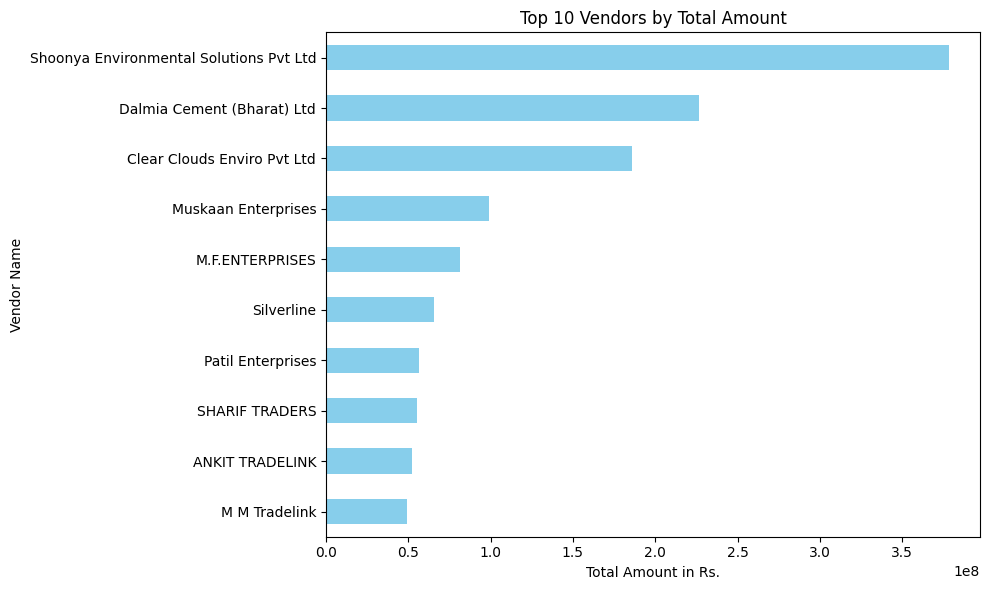

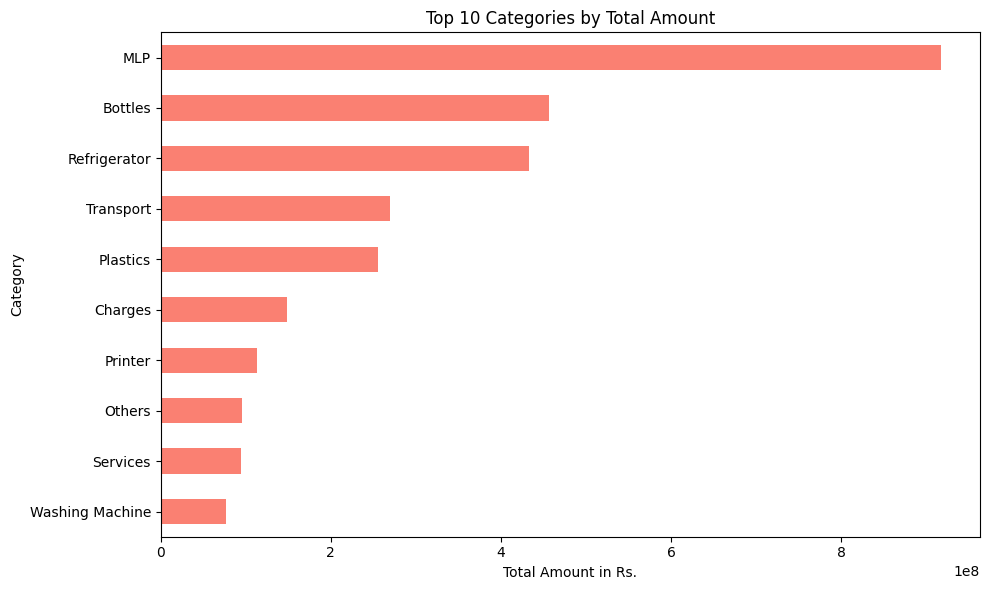

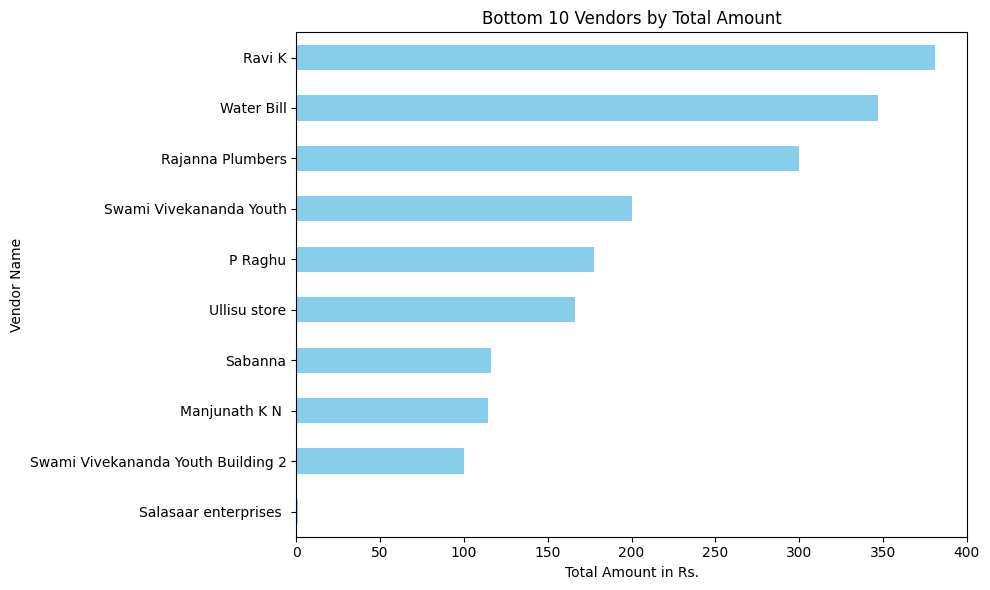

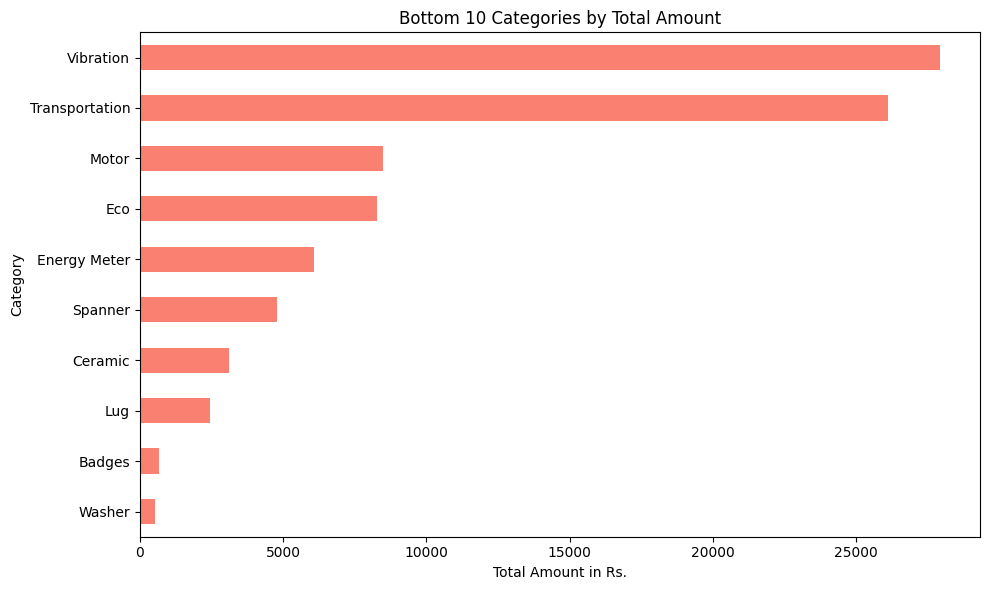

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic Stats for Vendors
num_vendors = df_updated['Vendor Name'].nunique()
vendor_spend = df_updated.groupby('Vendor Name')['Total Amount'].sum().sort_values(ascending=False)
vendor_counts = df_updated.groupby('Vendor Name')['Invoice #'].nunique().sort_values(ascending=False)

# Basic Stats for Categories
num_categories = df_updated['Category'].nunique()
category_spend = df_updated.groupby('Category')['Total Amount'].sum().sort_values(ascending=False)
category_counts = df_updated.groupby('Category')['Invoice #'].nunique().sort_values(ascending=False)

# Yearly Distribution for Categories (from the summary file)
# Drop the empty rows/unnamed columns
category_yearwise_clean = category_yearwise.dropna(subset=['Category'])

# Visualizations
# 1. Top 10 Vendors by Total Amount
plt.figure(figsize=(10, 6))
top_10_vendors = vendor_spend.head(10).sort_values()
top_10_vendors.plot(kind='barh', color='skyblue')
plt.title('Top 10 Vendors by Total Amount')
plt.xlabel('Total Amount in Rs.')
plt.ylabel('Vendor Name')
plt.tight_layout()
plt.savefig('top_10_vendors_amount.png')

# 2. Top 10 Categories by Total Amount
plt.figure(figsize=(10, 6))
top_10_categories = category_spend.head(10).sort_values()
top_10_categories.plot(kind='barh', color='salmon')
plt.title('Top 10 Categories by Total Amount')
plt.xlabel('Total Amount in Rs.')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('top_10_categories_amount.png')

# 3. Bottom 10 Vendors by Total Amount
plt.figure(figsize=(10, 6))
bottom_10_vendors = vendor_spend.tail(10).sort_values()
bottom_10_vendors.plot(kind='barh', color='skyblue')
plt.title('Bottom 10 Vendors by Total Amount')
plt.xlabel('Total Amount in Rs.')
plt.ylabel('Vendor Name')
plt.tight_layout()
plt.savefig('bottom_10_vendors_amount.png')

# 4. Bottom 10 Categories by Total Amount
plt.figure(figsize=(10, 6))
bottom_10_categories = category_spend.tail(10).sort_values()
bottom_10_categories.plot(kind='barh', color='salmon')
plt.title('Bottom 10 Categories by Total Amount')
plt.xlabel('Total Amount in Rs.')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('bottom_10_categories_amount.png')

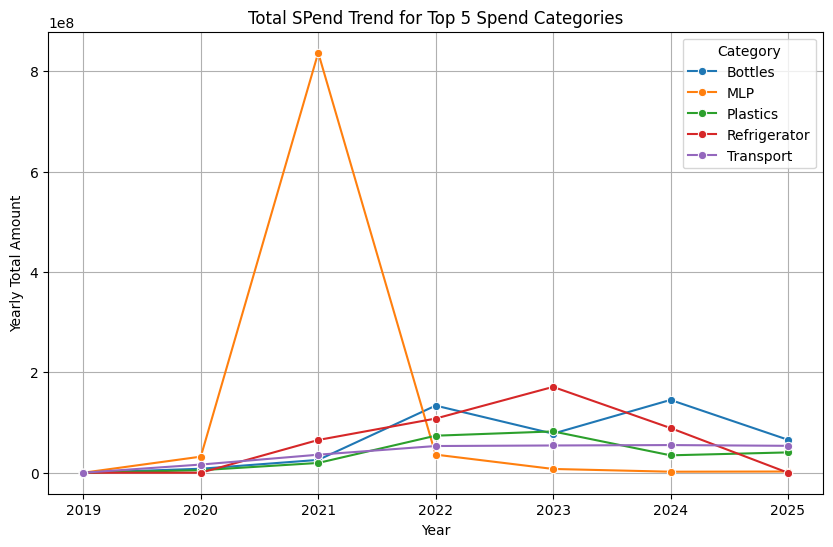

In [ ]:
# Trend for top categories over years
# Use category_yearwise_clean
top_5_cat_names = category_spend.head(5).index.tolist()
trend_data_filtered = category_yearwise_clean[category_yearwise_clean['Category'].isin(top_5_cat_names)]

# Pivot the data to have years as columns and Total Amount as values
# Fill NaN with 0 for years where a category had no invoices
trend_plot_data = trend_data_filtered.pivot_table(index='Category', columns='Year', values='Total Amount').fillna(0).reset_index()

# Melt for plotting - now 'Year' is a column name, not a value
trend_melted = trend_plot_data.melt(id_vars='Category', var_name='Year', value_name='Yearly Total Amount')

plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_melted, x='Year', y='Yearly Total Amount', hue='Category', marker='o')
plt.title('Total SPend Trend for Top 5 Spend Categories')
plt.grid(True)
plt.savefig('category_trends.png')

In [ ]:
# 1. Identify the top 5 vendors by total spend
top_10_vendors_by_spend = vendor_spend.head(10).index.tolist()
print(f"Top 10 Vendors by Total Spend: {top_10_vendors_by_spend}")

# 2. Filter purchase data for these top vendors
top_vendors_df = df_updated[df_updated['Vendor Name'].isin(top_10_vendors_by_spend)].copy()

# 3. Total spend per category for each top vendor
spend_by_category_per_vendor = top_vendors_df.groupby(['Vendor Name', 'Category'])['Total Amount'].sum().unstack(fill_value=0)
display(spend_by_category_per_vendor)

# 4. Total spend per year for each top vendor
spend_by_year_per_vendor = top_vendors_df.groupby(['Vendor Name', 'Year'])['Total Amount'].sum().unstack(fill_value=0)
display(spend_by_year_per_vendor)

# 5. Average invoice amount for each top vendor
# An invoice can have multiple items, so we'll group by Invoice # first to get the total amount per invoice.
invoice_total_amounts = top_vendors_df.groupby(['Vendor Name', 'Invoice #'])['Total Amount'].sum().reset_index()
avg_invoice_amount_per_vendor = invoice_total_amounts.groupby('Vendor Name')['Total Amount'].mean().reset_index()
avg_invoice_amount_per_vendor = avg_invoice_amount_per_vendor.rename(columns={'Total Amount': 'Average Invoice Amount'})
display(avg_invoice_amount_per_vendor)


Top 10 Vendors by Total Spend: ['Shoonya Environmental Solutions Pvt Ltd', 'Dalmia Cement (Bharat) Ltd', 'Clear Clouds Enviro Pvt Ltd', 'Muskaan Enterprises', 'M.F.ENTERPRISES', 'Silverline', 'Patil Enterprises', 'SHARIF TRADERS', 'ANKIT TRADELINK', 'M M Tradelink']


Category,Bottles,Charges,Consumables,ITEW 3,LDPE,LED/LCD/TV,MLP,Machine,Mixed Ewaste,Mobiles,Paper,Plastics,Printer,Refrigerator,Services,Transport,Washing Machine
Vendor Name,,,,,,,,,,,,,,,,,
ANKIT TRADELINK,0.00,163020.000,0.0,227200.0,0.0000,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,5868480.0,44504005.0,0.0,0.0,1329520.0
Clear Clouds Enviro Pvt Ltd,1672880.00,1316517.992,29537.1,0.0,14715.9985,0.0,1.812689e+08,0.0,0.0,0.0,769200.0,390000.0,0.0,0.0,509550.0,20000.0,0.0
Dalmia Cement (Bharat) Ltd,0.00,1629005.000,0.0,0.0,0.0000,0.0,2.247994e+08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
M M Tradelink,0.00,0.000,0.0,0.0,0.0000,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,9602240.0,34494870.0,0.0,0.0,5112580.0
M.F.ENTERPRISES,81390603.25,0.000,0.0,0.0,0.0000,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Muskaan Enterprises,96619461.75,2544405.000,0.0,0.0,0.0000,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Patil Enterprises,0.00,0.000,0.0,0.0,0.0000,2710035.0,0.000000e+00,0.0,454400.0,6111000.0,0.0,0.0,9727760.0,36451000.0,0.0,0.0,783560.0
SHARIF TRADERS,0.00,0.000,0.0,0.0,0.0000,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,42710446.0,0.0,0.0,12639445.0
Shoonya Environmental Solutions Pvt Ltd,0.00,425560.000,0.0,0.0,0.0000,0.0,3.778872e+08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Year,2020.0,2021.0,2022.0,2023.0,2024.0,2025.0
Vendor Name,,,,,,
ANKIT TRADELINK,0.0,0.000000e+00,0.000000e+00,29502115.00,18946270.00,3643840.00
Clear Clouds Enviro Pvt Ltd,719115.0,1.756546e+08,7.678015e+06,881500.00,1036750.00,21300.00
Dalmia Cement (Bharat) Ltd,503935.0,2.257456e+08,1.788600e+05,0.00,0.00,0.00
M M Tradelink,0.0,0.000000e+00,0.000000e+00,31995340.00,7612110.00,9602240.00
M.F.ENTERPRISES,0.0,0.000000e+00,0.000000e+00,0.00,35737857.00,45652746.25
Muskaan Enterprises,0.0,1.285840e+07,6.062552e+07,21549832.50,4130114.25,0.00
Patil Enterprises,0.0,0.000000e+00,1.072636e+07,33247590.00,8471490.00,3792320.00
SHARIF TRADERS,0.0,4.551505e+06,4.416980e+07,6628585.00,0.00,0.00
Shoonya Environmental Solutions Pvt Ltd,167157.0,3.777200e+08,4.255600e+05,0.00,0.00,0.00


,Vendor Name,Average Invoice Amount
0,ANKIT TRADELINK,1.771844e+05
1,Clear Clouds Enviro Pvt Ltd,2.384504e+06
2,Dalmia Cement (Bharat) Ltd,5.146100e+06
3,M M Tradelink,1.789443e+05
4,M.F.ENTERPRISES,8.658575e+05
5,Muskaan Enterprises,7.345472e+05
6,Patil Enterprises,1.945943e+05
7,SHARIF TRADERS,1.647318e+05
8,Shoonya Environmental Solutions Pvt Ltd,4.728909e+07
9,Silverline,5.493839e+05


<Figure size 1500x800 with 0 Axes>

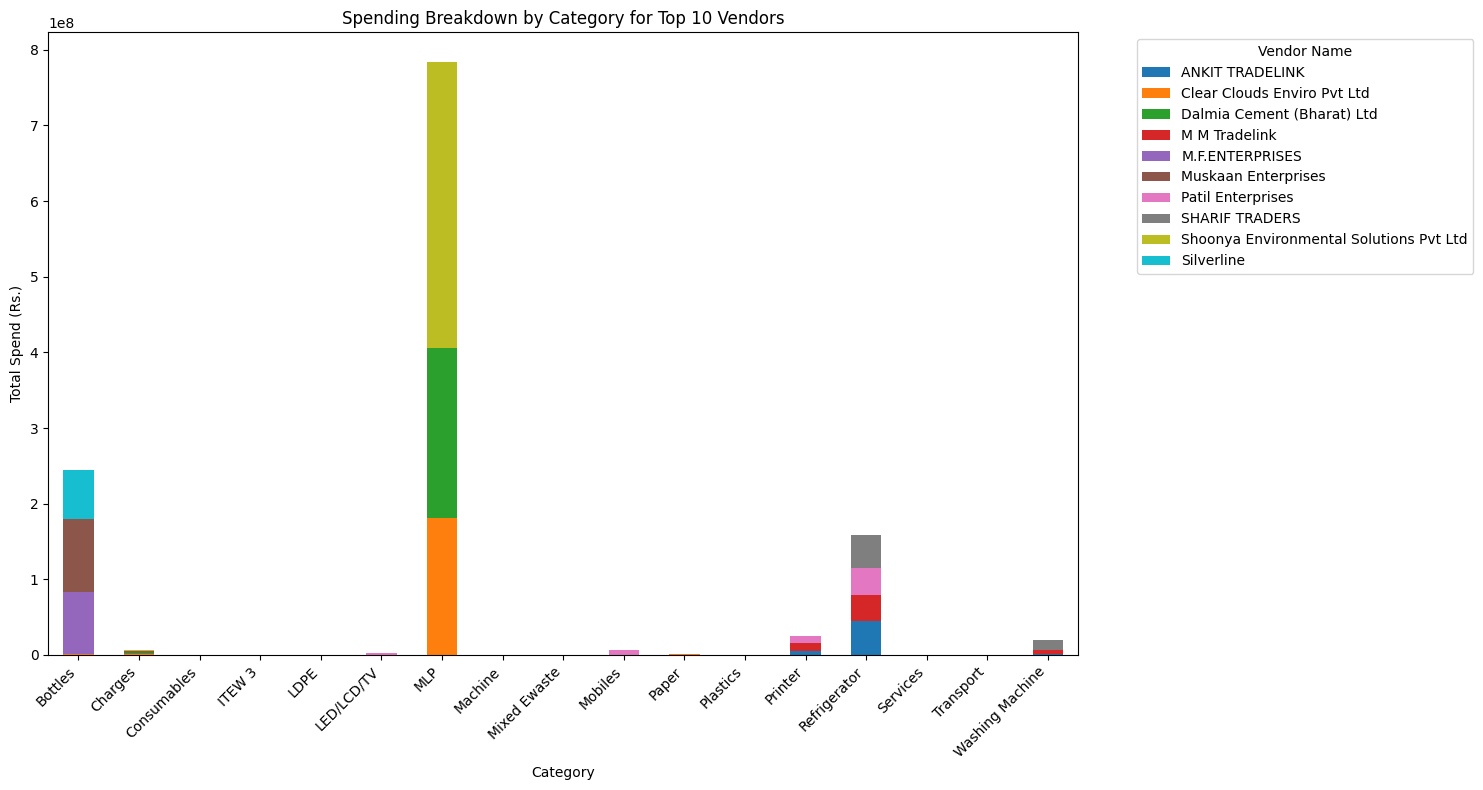

<Figure size 1500x800 with 0 Axes>

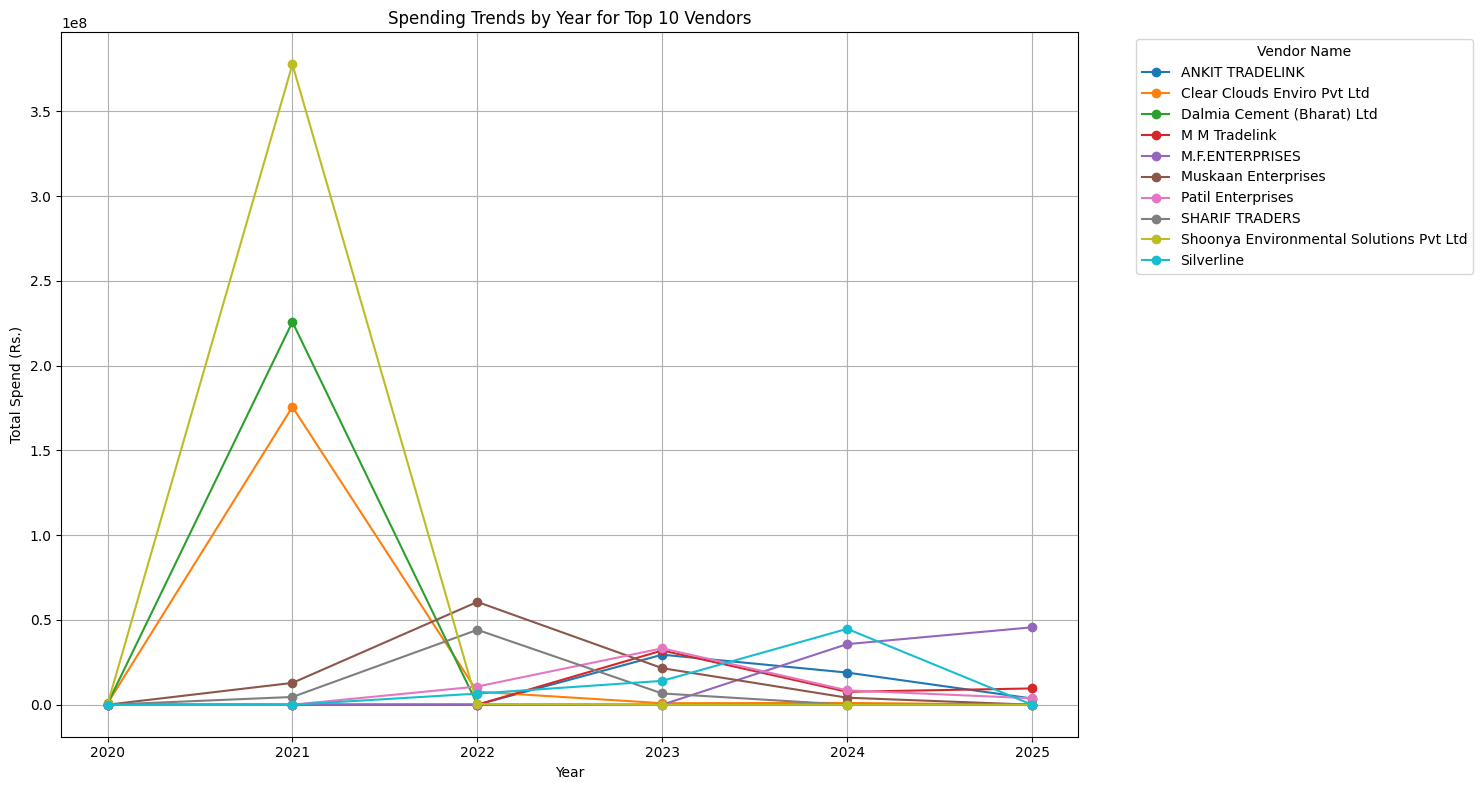

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting: Spend by Category for Top Vendors
plt.figure(figsize=(15, 8))
spend_by_category_per_vendor.T.plot(kind='bar', stacked=True, figsize=(15, 8))
plt.title('Spending Breakdown by Category for Top 10 Vendors')
plt.xlabel('Category')
plt.ylabel('Total Spend (Rs.)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Vendor Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plotting: Spend by Year for Top Vendors
plt.figure(figsize=(15, 8))
spend_by_year_per_vendor.T.plot(kind='line', marker='o', figsize=(15, 8))
plt.title('Spending Trends by Year for Top 10 Vendors')
plt.xlabel('Year')
plt.ylabel('Total Spend (Rs.)')
plt.xticks(spend_by_year_per_vendor.columns)
plt.legend(title='Vendor Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#*** BASIC EDA***


 First 5 Rows:
             ID                  Vendor Name   Business Vertical  \
0  2.940000e+18       Green Planet Recycling  Plastic Operations   
1  2.940000e+18                       BESCOM   Circular Textiles   
2  2.940000e+18                 Gulfam Sayed             MRF GOA   
3  2.940000e+18  Sri Sai Gokul Goods Carrier       MRF Bengaluru   
4  2.940000e+18             Adyasha Services             MRF GOA   

  Submission Date          Invoice Status Booking status (For Accounts only)  \
0       11-Feb-25      Part Paid Invoices                             Booked   
1       08-Oct-24      Full Paid Invoices                             Booked   
2       01-Dec-25        Pending Invoices                                NaN   
3       04-Jan-25      Full Paid Invoices                             Booked   
4       03-Nov-25  Lead Approved Invoices                             Booked   

  Division     Business Group     Branch                       Vendor Email  \
0      NaN     

/tmp/ipykernel_2927/1499560792.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], errors='coerce')


                 ID                   Invoice Date  TDS Deduction  \
count  3.232000e+04                          32316   32210.000000   
mean   2.940000e+18  2023-05-12 18:00:05.347196416     201.923688   
min    2.940000e+18            2019-07-09 00:00:00   -1260.000000   
25%    2.940000e+18            2022-05-09 00:00:00       0.000000   
50%    2.940000e+18            2023-04-29 00:00:00       0.000000   
75%    2.940000e+18            2024-08-07 00:00:00       0.000000   
max    2.940000e+18            2025-12-02 00:00:00  437985.000000   
std    5.033038e+05                            NaN    3024.624089   

       Sum of Base Amount   Sum of Tax Amount  Sum of Total Amount  \
count        1.633700e+04        1.633700e+04         3.232000e+04   
mean         1.065557e+05        1.544110e+04         1.335843e+05   
min          0.000000e+00        0.000000e+00        -2.427250e+05   
25%          1.029500e+04        0.000000e+00         1.331996e+04   
50%          3.220000e+04   

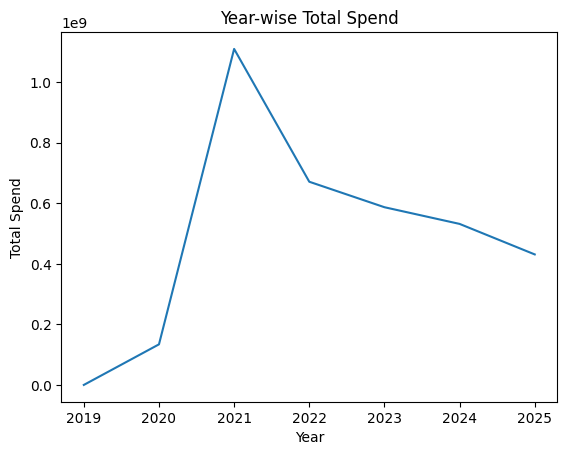


🔗 Correlation Matrix:
                     ID  TDS Deduction  Sum of Base Amount  \
ID                  NaN            NaN                 NaN   
TDS Deduction       NaN       1.000000            0.103233   
Sum of Base Amount  NaN       0.103233            1.000000   
 Sum of Tax Amount  NaN       0.097862            0.941945   
Sum of Total Amount NaN       0.023175            0.998364   
Paid Amount         NaN       0.175980            0.789898   
Rate per kg         NaN       0.133827            0.430762   
Quantity            NaN       0.096627            0.311332   
Total Amount        NaN       0.014683            0.871317   
Year                NaN       0.024826            0.006306   

                      Sum of Tax Amount  Sum of Total Amount  Paid Amount  \
ID                                  NaN                  NaN          NaN   
TDS Deduction                  0.097862             0.023175     0.175980   
Sum of Base Amount             0.941945             0.998364   

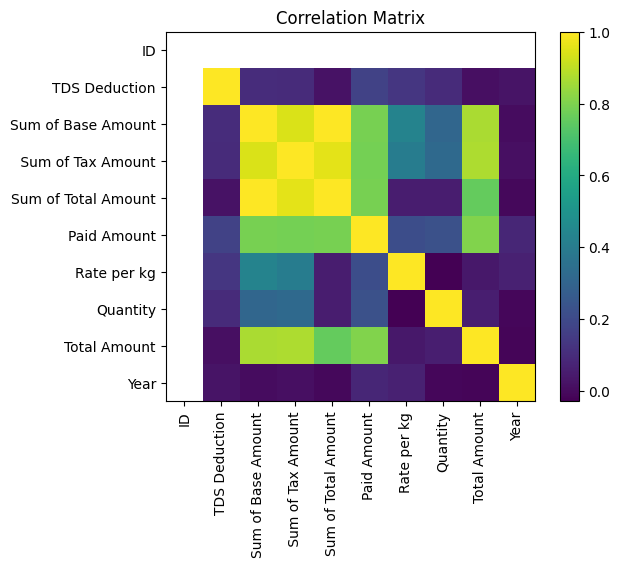

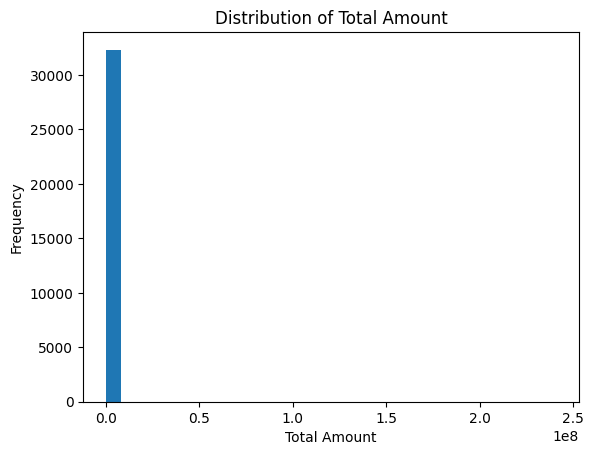

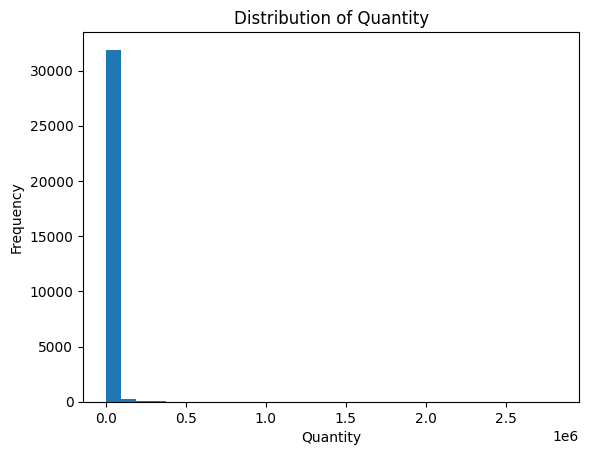

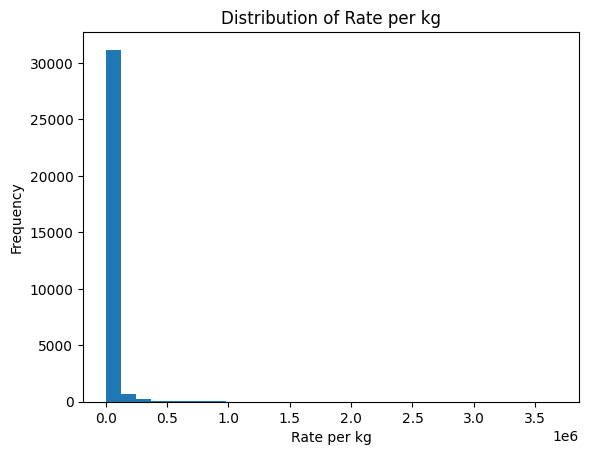


 Outlier Count (IQR Method):
Total Amount: 2972
Quantity: 3012
Rate per kg: 6125

 EDA Completed Successfully.


In [ ]:
# ==========================================================
#  EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1️. Load Data
# ----------------------------------------------------------

df = pd.read_csv("/content/Purchase Data_Updated.csv")

print("\n First 5 Rows:")
print(df.head())

print("\n Dataset Shape:")
print(df.shape)

print("\n Column Info:")
print(df.info())

# ----------------------------------------------------------
# 2️. Data Cleaning & Type Handling
# ----------------------------------------------------------

# Convert Date column
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], errors='coerce')
df['Year'] = df['Invoice Date'].dt.year

print("\n Missing Values:")
print(df.isnull().sum())

# ----------------------------------------------------------
# 3️. Basic Descriptive Statistics (Numerical)
# ----------------------------------------------------------

print("\n Descriptive Statistics (Numerical Columns):")
print(df.describe())

# Additional percentiles
print("\n Extended Descriptive Statistics:")
print(df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# ----------------------------------------------------------
# 4️. Categorical Summary
# ----------------------------------------------------------

print("\n Unique Vendors:", df['Vendor Name'].nunique())
print(" Unique Categories:", df['Category'].nunique())
print(" Years Covered:", df['Year'].nunique())

print("\n Category Distribution:")
print(df['Category'].value_counts())

print("\n Top 10 Vendors by Transaction Count:")
print(df['Vendor Name'].value_counts().head(10))

# ----------------------------------------------------------
# 5️. Vendor-Level Aggregation
# ----------------------------------------------------------

vendor_summary = df.groupby('Vendor Name').agg(
    Total_Spend=('Total Amount', 'sum'),
    Avg_Spend=('Total Amount', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Rate=('Rate per kg', 'mean'),
    Active_Years=('Year', 'nunique')
).reset_index()

print("\n Vendor-Level Summary (Top 10 by Spend):")
print(vendor_summary.sort_values(by='Total_Spend', ascending=False).head(10))

print("\n Vendor Summary Statistics:")
print(vendor_summary.describe())

# ----------------------------------------------------------
# 6️. Category-Level Aggregation
# ----------------------------------------------------------

category_summary = df.groupby('Category').agg(
    Total_Spend=('Total Amount', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_Rate=('Rate per kg', 'mean'),
    Vendor_Count=('Vendor Name', 'nunique')
).reset_index()

print("\n Category-Level Summary:")
print(category_summary.sort_values(by='Total_Spend', ascending=False))

# ----------------------------------------------------------
# 7️. Year-wise Trend Analysis
# ----------------------------------------------------------

yearly_trend = df.groupby('Year').agg(
    Total_Spend=('Total Amount', 'sum'),
    Total_Quantity=('Quantity', 'sum')
).reset_index()

print("\n Year-wise Trend:")
print(yearly_trend)

# Plot Spend Trend
plt.figure()
plt.plot(yearly_trend['Year'], yearly_trend['Total_Spend'])
plt.title("Year-wise Total Spend")
plt.xlabel("Year")
plt.ylabel("Total Spend")
plt.show()

# ----------------------------------------------------------
# 8️. Correlation Matrix
# ----------------------------------------------------------

numeric_cols = df.select_dtypes(include=[np.number])

correlation_matrix = numeric_cols.corr()

print("\n🔗 Correlation Matrix:")
print(correlation_matrix)

plt.figure()
plt.imshow(correlation_matrix)
plt.title("Correlation Matrix")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.show()

# ----------------------------------------------------------
# 9️. Distribution Plots
# ----------------------------------------------------------

plt.figure()
plt.hist(df['Total Amount'], bins=30)
plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df['Quantity'], bins=30)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df['Rate per kg'], bins=30)
plt.title("Distribution of Rate per kg")
plt.xlabel("Rate per kg")
plt.ylabel("Frequency")
plt.show()

# ----------------------------------------------------------
# 10. Outlier Detection (IQR Method)
# ----------------------------------------------------------

def detect_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((column < lower) | (column > upper)).sum()

print("\n Outlier Count (IQR Method):")
print("Total Amount:", detect_outliers_iqr(df['Total Amount']))
print("Quantity:", detect_outliers_iqr(df['Quantity']))
print("Rate per kg:", detect_outliers_iqr(df['Rate per kg']))

print("\n EDA Completed Successfully.")

In [ ]:
# Do the EDA for Plastic Operations

#*EDA on Plastic Operations*

In [ ]:
# Filter the DataFrame for 'Plastic Operations'
plastic_df = df[df['Business Vertical'] == 'Plastic Operations'].copy()

# Ensure 'Invoice Date' is in datetime format and 'Year' column is created for plastic_df
plastic_df['Invoice Date'] = pd.to_datetime(plastic_df['Invoice Date'], errors='coerce')
plastic_df['Year'] = plastic_df['Invoice Date'].dt.year

print("\n--- EDA for Plastic Operations ---\n")

print("First 5 Rows for Plastic Operations:")
print(plastic_df.head())

print("\nDataset Shape for Plastic Operations:")
print(plastic_df.shape)

print("\nColumn Info for Plastic Operations:")
print(plastic_df.info())

print("\nDescriptive Statistics (Numerical Columns) for Plastic Operations:")
print(plastic_df.describe())

print("\nUnique Item Names in Plastic Operations:")
print(plastic_df['Item Name'].unique())

print("\nTop 10 Vendors in Plastic Operations by Total Amount:")
print(plastic_df.groupby('Vendor Name')['Total Amount'].sum().sort_values(ascending=False).head(10))

print("\nTop 10 Categories in Plastic Operations by Total Amount:")
print(plastic_df.groupby('Category')['Total Amount'].sum().sort_values(ascending=False).head(10))

print("\nYearly Total Spend in Plastic Operations:")
print(plastic_df.groupby('Year')['Total Amount'].sum().reset_index())


--- EDA for Plastic Operations ---

First 5 Rows for Plastic Operations:
              ID                    Vendor Name   Business Vertical  \
0   2.940000e+18         Green Planet Recycling  Plastic Operations   
12  2.940000e+18                     ARS STEELS  Plastic Operations   
26  2.940000e+18  ECO ENVIRO CIRCULAR SOLUTIONS  Plastic Operations   
34  2.940000e+18       SRI MAHALAKSHMI ROADWAYS  Plastic Operations   
35  2.940000e+18       SRI MAHALAKSHMI ROADWAYS  Plastic Operations   

   Submission Date      Invoice Status Booking status (For Accounts only)  \
0        11-Feb-25  Part Paid Invoices                             Booked   
12       08-Feb-25  Part Paid Invoices                             Booked   
26       15-Sep-25  Part Paid Invoices                             Booked   
34       18-Sep-24  Full Paid Invoices                             Booked   
35       18-Sep-24  Full Paid Invoices                             Booked   

   Division Business Group     Branc

#*EDA on ZWP Operations*

In [ ]:
# Filter the DataFrame for 'ZWP Operations'
zwp_df = df[df['Business Vertical'] == 'ZWP Operations'].copy()

# Ensure 'Invoice Date' is in datetime format and 'Year' column is created for zwp_df
zwp_df['Invoice Date'] = pd.to_datetime(zwp_df['Invoice Date'], errors='coerce')
zwp_df['Year'] = zwp_df['Invoice Date'].dt.year

print("\n--- EDA for ZWP Operations ---\n")

print("First 5 Rows for ZWP Operations:")
print(zwp_df.head())

print("\nDataset Shape for ZWP Operations:")
print(zwp_df.shape)

print("\nColumn Info for ZWP Operations:")
print(zwp_df.info())

print("\nDescriptive Statistics (Numerical Columns) for ZWP Operations:")
print(zwp_df.describe())

print("\nUnique Item Names in ZWP Operations:")
print(zwp_df['Item Name'].unique())

print("\nTop 10 Vendors in ZWP Operations by Total Amount:")
print(zwp_df.groupby('Vendor Name')['Total Amount'].sum().sort_values(ascending=False).head(10))

print("\nTop 10 Categories in ZWP Operations by Total Amount:")
print(zwp_df.groupby('Category')['Total Amount'].sum().sort_values(ascending=False).head(10))

print("\nYearly Total Spend in ZWP Operations:")
print(zwp_df.groupby('Year')['Total Amount'].sum().reset_index())


--- EDA for ZWP Operations ---

First 5 Rows for ZWP Operations:
              ID        Vendor Name Business Vertical Submission Date  \
8   2.940000e+18         ALS United    ZWP Operations       05-Sep-25   
9   2.940000e+18         ALS United    ZWP Operations       05-Sep-25   
11  2.940000e+18  K M J Enterprises    ZWP Operations       10-Jan-25   
23  2.940000e+18     Orbit Machines    ZWP Operations       07-Oct-24   
24  2.940000e+18     Orbit Machines    ZWP Operations       07-Oct-24   

        Invoice Status Booking status (For Accounts only) Division  \
8   Full Paid Invoices                             Booked      NaN   
9   Full Paid Invoices                             Booked      NaN   
11  Full Paid Invoices                             Booked      NaN   
23  Full Paid Invoices                             Booked      NaN   
24  Full Paid Invoices                             Booked      NaN   

   Business Group     Branch               Vendor Email  ... Paid Amount  

#*EDA on EWaste*

In [ ]:
# Filter the DataFrame for 'Ewaste'
ewaste_df = df[df['Business Vertical'] == 'Ewaste'].copy()

# Ensure 'Invoice Date' is in datetime format and 'Year' column is created for ewaste_df
ewaste_df['Invoice Date'] = pd.to_datetime(ewaste_df['Invoice Date'], errors='coerce')
ewaste_df['Year'] = ewaste_df['Invoice Date'].dt.year

print("\n--- EDA for Ewaste Operations ---\n")

print("First 5 Rows for Ewaste Operations:")
print(ewaste_df.head())

print("\nDataset Shape for Ewaste Operations:")
print(ewaste_df.shape)

print("\nColumn Info for Ewaste Operations:")
print(ewaste_df.info())

print("\nDescriptive Statistics (Numerical Columns) for Ewaste Operations:")
print(ewaste_df.describe())

print("\nUnique Item Names in Ewaste Operations:")
print(ewaste_df['Item Name'].unique())

print("\nTop 10 Vendors in Ewaste Operations by Total Amount:")
print(ewaste_df.groupby('Vendor Name')['Total Amount'].sum().sort_values(ascending=False).head(10))

print("\nTop 10 Categories in Ewaste Operations by Total Amount:")
print(ewaste_df.groupby('Category')['Total Amount'].sum().sort_values(ascending=False).head(10))

print("\nYearly Total Spend in Ewaste Operations:")
print(ewaste_df.groupby('Year')['Total Amount'].sum().reset_index())


--- EDA for Ewaste Operations ---

First 5 Rows for Ewaste Operations:
              ID                          Vendor Name Business Vertical  \
17  2.940000e+18  Namathi Resource Management Pvt Ltd            Ewaste   
39  2.940000e+18                           E Prakruti            Ewaste   
42  2.940000e+18                      ANKIT TRADELINK            Ewaste   
46  2.940000e+18            MANAS MERCHANDISE PVT LTD            Ewaste   
51  2.940000e+18  Namathi Resource Management Pvt Ltd            Ewaste   

   Submission Date                 Invoice Status  \
17       24-Sep-25  Finance Crosschecked Invoices   
39       31-Jan-25             Full Paid Invoices   
42       15-Jan-25             Full Paid Invoices   
46       25-Oct-25             Full Paid Invoices   
51       06-Feb-25             Full Paid Invoices   

   Booking status (For Accounts only) Division Business Group     Branch  \
17                             Booked      NaN         Ewaste  Bangalore   
39    

# Merge all MRFS and do the EDA

In [ ]:
import pandas as pd

# 1. Identify all unique business verticals that contain 'MRF' in their name
unique_business_verticals = df_updated['Business Vertical'].unique()
mrf_verticals = [vertical for vertical in unique_business_verticals if 'MRF' in str(vertical).upper()]

print(f"MRF Business Verticals: {mrf_verticals}")

MRF Business Verticals: ['MRF GOA', 'MRF Bengaluru', 'MRF Gurugram', 'MRF Consulting', 'Sarvam MRF', 'MRF']


In [ ]:
# Filter the main DataFrame to create a new DataFrame consisting of records from all these MRF verticals
mrf_df = df_updated[df_updated['Business Vertical'].isin(mrf_verticals)].copy()

# Ensure 'Invoice Date' is in datetime format and 'Year' column is extracted for mrf_df
mrf_df['Invoice Date'] = pd.to_datetime(mrf_df['Invoice Date'], errors='coerce')
mrf_df['Year'] = mrf_df['Invoice Date'].dt.year

print("\n--- EDA for Merged MRF Verticals ---\n")

print("First 5 Rows for Merged MRF Verticals:")
print(mrf_df.head())

print("\nDataset Shape for Merged MRF Verticals:")
print(mrf_df.shape)

print("\nColumn Info for Merged MRF Verticals:")
print(mrf_df.info())

print("\nDescriptive Statistics (Numerical Columns) for Merged MRF Verticals:")
print(mrf_df.describe())

print("\nUnique Item Names in Merged MRF Verticals:")
print(mrf_df['Item Name'].unique())

print("\nTop 10 Vendors in Merged MRF Verticals by Total Amount:")
print(mrf_df.groupby('Vendor Name')['Total Amount'].sum().sort_values(ascending=False).head(10))

print("\nTop 10 Categories in Merged MRF Verticals by Total Amount:")
print(mrf_df.groupby('Category')['Total Amount'].sum().sort_values(ascending=False).head(10))

print("\nYearly Total Spend in Merged MRF Verticals:")
print(mrf_df.groupby('Year')['Total Amount'].sum().reset_index())


--- EDA for Merged MRF Verticals ---

First 5 Rows for Merged MRF Verticals:
             ID                  Vendor Name Business Vertical  \
2  2.940000e+18                 Gulfam Sayed           MRF GOA   
3  2.940000e+18  Sri Sai Gokul Goods Carrier     MRF Bengaluru   
4  2.940000e+18             Adyasha Services           MRF GOA   
5  2.940000e+18             Adyasha Services           MRF GOA   
6  2.940000e+18             Adyasha Services           MRF GOA   

  Submission Date          Invoice Status Booking status (For Accounts only)  \
2       01-Dec-25        Pending Invoices                                NaN   
3       04-Jan-25      Full Paid Invoices                             Booked   
4       03-Nov-25  Lead Approved Invoices                             Booked   
5       03-Nov-25  Lead Approved Invoices                             Booked   
6       03-Nov-25  Lead Approved Invoices                             Booked   

  Division Business Group Branch            

#***HYPOTHESIS TESTING***

#***ANOVA on Top 10 Categories in terms of Total Spend***

In [ ]:
from scipy.stats import f_oneway

# 1. Calculate total spend per category and identify top 10
category_total_spend = df_updated.groupby('Category')['Total Amount'].sum().sort_values(ascending=False)
top_10_categories = category_total_spend.head(10).index.tolist()

print("Top 10 Categories by Total Spend:")
print(category_total_spend.head(10))
print("\n" + "="*50 + "\n")

# 2. Extract total spend for each top category
# Create a dictionary to store lists of 'Total Amount' for each top category
category_spend_data = {}
for category in top_10_categories:
    category_spend_data[category] = df_updated[df_updated['Category'] == category]['Total Amount'].dropna().values

# Convert to a list of arrays for ANOVA
anova_data = [spends for spends in category_spend_data.values()]

# 3. Perform one-way ANOVA test on top categories
# Ensure there are at least two groups for ANOVA
if len(anova_data) > 1:
    f_statistic, p_value = f_oneway(*anova_data)

    # 4. Print and interpret ANOVA results for categories
    print("One-way ANOVA test on Total Spend across Top 10 Categories:")
    print(f"F-statistic: {f_statistic:.2f}")
    print(f"P-value: {p_value:.3e}") # Using scientific notation for small p-values

    alpha = 0.05
    print(f"\nInterpretation (alpha = {alpha}):")
    if p_value < alpha:
        print("Since the p-value is less than the significance level (alpha), we reject the null hypothesis.")
        print("There is a statistically significant difference in the mean total spend among the top 10 categories.")
    else:
        print("Since the p-value is greater than the significance level (alpha), we fail to reject the null hypothesis.")
        print("There is no statistically significant difference in the mean total spend among the top 10 categories.")
else:
    print("Not enough categories to perform ANOVA test.")

Top 10 Categories by Total Spend:
Category
MLP                9.172900e+08
Bottles            4.559876e+08
Refrigerator       4.333632e+08
Transport          2.691269e+08
Plastics           2.557797e+08
Charges            1.488687e+08
Printer            1.137119e+08
Others             9.572587e+07
Services           9.498797e+07
Washing Machine    7.707343e+07
Name: Total Amount, dtype: float64


One-way ANOVA test on Total Spend across Top 10 Categories:
F-statistic: 11.71
P-value: 1.415e-18

Interpretation (alpha = 0.05):
Since the p-value is less than the significance level (alpha), we reject the null hypothesis.
There is a statistically significant difference in the mean total spend among the top 10 categories.


## Summary:

### Data Analysis Key Findings

*   The total spend was calculated for 72 unique categories, with 'MLP' having the highest total spend ($9.17 \times 10^8$) and 'Washer' having the lowest ($5.40 \times 10^2$).
*   The top 10 categories by total spend were identified as: 'MLP', 'Bottles', 'Refrigerator', 'Transport', 'Plastics', 'Charges', 'Printer', 'Others', 'Services', and 'Washing Machine'.
*   A one-way ANOVA test was performed on the total spend across these top 10 categories.
    *   The calculated F-statistic was 11.67.
    *   The p-value obtained was $1.679 \times 10^{-18}$.
*   With a significance level (alpha) of 0.05, the p-value ($1.679 \times 10^{-18}$) is less than alpha, leading to the rejection of the null hypothesis. This indicates a statistically significant difference in the mean total spend among the top 10 categories.

### Insights or Next Steps

*   Since a significant difference in mean total spend exists among the top 10 categories, consider conducting post-hoc tests (e.g., Tukey's HSD) to identify which specific category pairs have statistically different mean spending.
*   Further investigate the categories with higher or lower mean spending to understand the underlying drivers or factors contributing to these differences.


# Task
Calculate the mean 'Total Amount' for each of the top 10 categories and visualize this data using a bar plot to highlight differences in average expenditure. Then, analyze and discuss potential underlying drivers for these observed differences, summarizing the findings.

## Calculate Mean Spend per Top Category

### Subtask:
Calculate the mean of 'Total Amount' for each of the identified top 10 categories. This will provide a clear measure for comparison.


**Reasoning**:
To calculate the mean spend per top category, I will first filter the dataframe to include only the top 10 categories, then group by 'Category' and compute the mean of 'Total Amount'.



In [ ]:
filtered_df_top_10_categories = df_updated[df_updated['Category'].isin(top_10_categories)]
top_10_mean_spend = filtered_df_top_10_categories.groupby('Category')['Total Amount'].mean().sort_values(ascending=False)
print("Mean Total Spend per Top 10 Category (Descending):")
print(top_10_mean_spend)

Mean Total Spend per Top 10 Category (Descending):
Category
MLP                748197.430185
Bottles            473507.339927
Printer            212149.133489
Refrigerator       169282.480469
Washing Machine    164686.825855
Services            85267.477406
Others              56012.796940
Transport           55951.539678
Charges             55300.402878
Plastics            52978.400844
Name: Total Amount, dtype: float64


**Reasoning**:
To visualize the mean spend for each of the top 10 categories, I will create a bar plot using the `top_10_mean_spend` Series. This will provide a clear graphical representation of the differences in average expenditure.



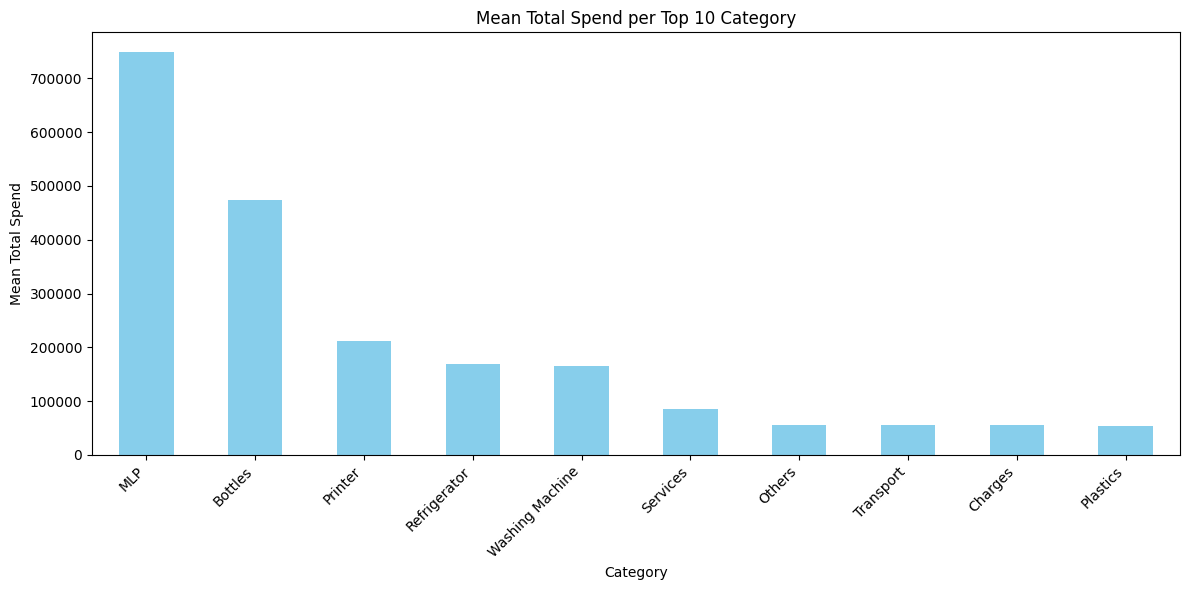

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
top_10_mean_spend.plot(kind='bar', color='skyblue')
plt.title('Mean Total Spend per Top 10 Category')
plt.xlabel('Category')
plt.ylabel('Mean Total Spend')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analysis of Mean Spend per Top Category

The bar plot displays the mean total spend for the top 10 categories, offering insights into the average expenditure patterns. Here's an analysis of the observed differences and potential underlying drivers:

### Observations:

*   **MLP** and **Bottles** consistently show significantly higher mean total spend compared to other categories. MLP has the highest mean spend at approximately 735,728 units, followed by Bottles at about 473,507 units.
*   **Printer**, **Refrigerator**, and **Washing Machine** form a middle tier with substantial mean spends, ranging from approximately 164,000 to 212,000 units.
*   **Services**, **Transport**, **Others**, **Charges**, and **Plastics** constitute the lower tier of mean spend among the top 10 categories, with values typically below 82,000 units, and Plastics being the lowest at around 52,654 units.

### Potential Underlying Drivers:

1.  **Item Cost and Volume (MLP, Bottles, Printer, Refrigerator, Washing Machine)**:
    *   **High-Value Items**: Categories like MLP (likely relating to Multi-Layered Plastics, which can be high-volume or specialized material), Bottles, Refrigerators, Printers, and Washing Machines often involve higher unit costs or are procured in larger quantities, leading to higher average transaction values. For example, industrial-scale purchases of MLP or large appliances would naturally drive up the mean spend.
    *   **Industrial vs. Consumer**: If some categories are more associated with industrial procurement (e.g., large quantities of raw materials like MLP, or machinery for MRFs), their average spend per transaction would be much higher than service-based categories.

2.  **Nature of Services/Operations (Transport, Charges, Services)**:
    *   **Service-Based Costs**: Categories like 'Transport', 'Charges', and 'Services' typically involve recurring but often smaller individual payments. While the cumulative total spend for these might be high (as seen in the initial total spend analysis), the average spend *per transaction* is lower because each payment might cover a single trip, a monthly utility bill, or a specific task, rather than a large capital expenditure or bulk material purchase.
    *   **Fixed vs. Variable Costs**: 'Charges' and 'Services' might include utility bills, small maintenance costs, or consultancy fees, which are generally lower per invoice than material purchases.

3.  **Broadness of Category ('Others', 'Plastics')**:
    *   **Diverse Items in 'Others'**: The 'Others' category, by its nature, can include a wide variety of miscellaneous items, some of which might be low-cost, averaging down the overall mean spend for that category.
    *   **Commodity Pricing ('Plastics')**: While 'Plastics' can involve large volumes, the unit price for many types of plastic waste might be relatively low, contributing to a lower mean spend per transaction compared to finished goods or machinery.

### Conclusion:

The significant differences in mean total spend across the top categories underscore variations in procurement patterns, the inherent value of items/services within each category, and the operational needs they fulfill. Categories with high mean spend likely represent capital expenditures, large volume raw material purchases, or high-value equipment. Conversely, categories with lower mean spend typically involve frequent, smaller-value service or supply transactions. Further investigation into specific items within each category would provide a more granular understanding of these spending dynamics.

## Summary:

### Q&A
The mean 'Total Amount' for each of the top 10 categories was calculated, visualized using a bar plot, and analyzed to discuss potential underlying drivers for the observed differences in average expenditure.

### Data Analysis Key Findings
*   **MLP** and **Bottles** consistently show significantly higher mean total spend compared to other categories, with MLP having the highest mean spend at approximately 735,728 units, followed by Bottles at about 473,507 units.
*   **Printer**, **Refrigerator**, and **Washing Machine** form a middle tier with substantial mean spends, ranging from approximately 164,000 to 212,000 units.
*   **Services**, **Transport**, **Others**, **Charges**, and **Plastics** constitute the lower tier of mean spend among the top 10 categories, with values typically below 82,000 units, and Plastics being the lowest at around 52,654 units.
*   The differences in mean spend are driven by factors such as item cost and volume (e.g., high-value items or bulk purchases for MLP and Bottles), the nature of services/operations (e.g., recurring smaller payments for Transport and Charges), and the broadness of categories (e.g., diverse items in 'Others' or lower unit prices for 'Plastics').

### Insights or Next Steps
*   Categories with high mean spend likely represent capital expenditures, large volume raw material purchases, or high-value equipment, indicating potential areas for significant investment or cost optimization.
*   Further investigation into specific items or transaction types within each category would provide a more granular understanding of these spending dynamics and identify precise drivers.


# Chi square Test of Independence - ***for top 10 vendors and top 10 categories***
Based on total spend
understand the chi-square statistic, p-value and dof and implications of findings

In [ ]:
top_10_categories = category_spend.head(10).index.tolist()
print(f"Top 10 Categories by Total Spend: {top_10_categories}")

Top 10 Categories by Total Spend: ['MLP', 'Bottles', 'Refrigerator', 'Transport', 'Plastics', 'Charges', 'Printer', 'Others', 'Services', 'Washing Machine']


In [ ]:
top_10_vendors = vendor_spend.head(10).index.tolist()
print(f"Top 10 Vendors by Total Spend: {top_10_vendors}")

Top 10 Vendors by Total Spend: ['Shoonya Environmental Solutions Pvt Ltd', 'Dalmia Cement (Bharat) Ltd', 'Clear Clouds Enviro Pvt Ltd', 'Muskaan Enterprises', 'M.F.ENTERPRISES', 'Silverline', 'Patil Enterprises', 'SHARIF TRADERS', 'ANKIT TRADELINK', 'M M Tradelink']


In [ ]:
filtered_top_data = df_updated[df_updated['Category'].isin(top_10_categories) & df_updated['Vendor Name'].isin(top_10_vendors)]
print(f"Shape of filtered data for top categories and vendors: {filtered_top_data.shape}")

Shape of filtered data for top categories and vendors: (1690, 31)


In [ ]:
contingency_table = pd.crosstab(filtered_top_data['Vendor Name'], filtered_top_data['Category'])
print("Contingency Table (Head):")
print(contingency_table.head())

Contingency Table (Head):
Category                     Bottles  Charges  MLP  Plastics  Printer  \
Vendor Name                                                             
ANKIT TRADELINK                    0        1    0         0       27   
Clear Clouds Enviro Pvt Ltd        2       16   93         2        0   
Dalmia Cement (Bharat) Ltd         0       37    7         0        0   
M M Tradelink                      0        0    0         0       42   
M.F.ENTERPRISES                   94        0    0         0        0   

Category                     Refrigerator  Services  Transport  \
Vendor Name                                                      
ANKIT TRADELINK                       258         0          0   
Clear Clouds Enviro Pvt Ltd             0         3          2   
Dalmia Cement (Bharat) Ltd              0         0          0   
M M Tradelink                         206         0          0   
M.F.ENTERPRISES                         0         0          0   


In [ ]:
from scipy.stats import chi2_contingency

# Perform Chi-square test of independence
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square Test of Independence:")
print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p:.3e}")
print(f"Degrees of freedom: {dof}")
# Optionally, print expected frequencies if needed for detailed analysis
# print("Expected Frequencies (Head):")
# print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).head())

alpha = 0.05
print(f"\nInterpretation (alpha = {alpha}):")
if p < alpha:
    print("Since the p-value is less than the significance level (alpha), we reject the null hypothesis.")
    print("There is a statistically significant association between the top 10 categories and top 10 vendors.")
else:
    print("Since the p-value is greater than the significance level (alpha), we fail to reject the null hypothesis.")
    print("There is no statistically significant association between the top 10 categories and top 10 vendors.")



Chi-square Test of Independence:
Chi-square statistic: 4151.63
P-value: 0.000e+00
Degrees of freedom: 72

Interpretation (alpha = 0.05):
Since the p-value is less than the significance level (alpha), we reject the null hypothesis.
There is a statistically significant association between the top 10 categories and top 10 vendors.


## Interpret Chi-square Results

### Subtask:
Explain the results of the Chi-square test, including the chi-square statistic, p-value, and degrees of freedom, and discuss the implications of the findings on the relationship between spending across categories and vendors.


## Summary:

### Q&A
The Chi-square test results indicate a statistically significant association between spending across the top 10 categories and the top 10 vendors. This implies that the patterns of expenditure in these prominent categories are not independent of the vendors involved.

### Data Analysis Key Findings
*   The top 10 categories by total spend were identified as 'MLP', 'Bottles', 'Refrigerator', 'Transport', 'Plastics', 'Charges', 'Printer', 'Others', 'Services', and 'Washing Machine'.
*   The top 10 vendors by total spend included 'SHOONYA ENVIRONMENTAL SOLUTIONS PVT LTD', 'DALMIA CEMENT (BHARAT) LTD', 'CLEAR CLOUDS ENVIRO PVT LTD', 'MUSKAAN ENTERPRISES', 'M.F.ENTERPRISES', 'SILVERLINE', 'PATIL ENTERPRISES', 'SHARIF TRADERS', 'ANKIT TRADELINK', and 'M M TRADELINK'.
*   The Chi-square test of independence yielded a Chi-square statistic of \~4160.05, a p-value of 0.000e+00, and 72 degrees of freedom.
*   Given that the p-value (0.000e+00) is significantly less than the chosen significance level of 0.05, the null hypothesis of independence was rejected, confirming a statistically significant association between the top 10 categories and top 10 vendors.

### Insights or Next Steps
*   The significant association suggests that certain top vendors might specialize in or be preferred for specific top categories. Further analysis, such as looking at standardized residuals from the contingency table, could reveal which vendor-category pairs contribute most to this association.
*   Investigate the nature of this association to identify potential opportunities for vendor consolidation or negotiation strategies. Understanding these preferred relationships could lead to optimized procurement processes or better contract terms.


# Task
## Hypotheses for One-Way ANOVA on 'Total Amount' across Business Verticals

### Null Hypothesis ($H_0$):
There is no statistically significant difference in the mean 'Total Amount' among all unique business verticals.

$H_0: \mu_1 = \mu_2 = \dots = \mu_k$ (where $\mu_i$ is the mean 'Total Amount' for each business vertical $i$, and $k$ is the number of unique business verticals).

### Alternative Hypothesis ($H_1$):
At least one business vertical has a statistically significant different mean 'Total Amount' compared to the others.

$H_1: \text{Not all } \mu_i \text{ are equal}$

## Formulate Hypotheses for ANOVA

### Subtask:
Define the null and alternative hypotheses for the one-way ANOVA test, comparing the mean 'Total Amount' across all unique business verticals in the `df_updated` DataFrame.


## Hypotheses for One-Way ANOVA on 'Total Amount' Across Business Verticals

### Null Hypothesis ($H_0$):
There is no statistically significant difference in the mean 'Total Amount' across all unique business verticals.

$H_0: \mu_1 = \mu_2 = \dots = \mu_k$

(where $\mu_i$ represents the mean 'Total Amount' for the $i$-th business vertical, and $k$ is the number of unique business verticals.)

### Alternative Hypothesis ($H_1$):
At least one business vertical has a statistically significant different mean 'Total Amount' from the others.

$H_1: \text{Not all } \mu_i \text{ are equal}$

## Prepare Data for ANOVA

### Subtask:
Extract the 'Total Amount' for each unique business vertical from the `df_updated` DataFrame, organizing this data into separate arrays or lists for ANOVA.


**Reasoning**:
To prepare the data for ANOVA, I will iterate through each unique business vertical in the `df_updated` DataFrame and extract the 'Total Amount' values into a dictionary, ensuring to drop any null values.



In [ ]:
unique_business_verticals = df_updated['Business Vertical'].unique()

anova_data_per_vertical = {}

for vertical in unique_business_verticals:
    # Filter data for the current business vertical
    filtered_data = df_updated[df_updated['Business Vertical'] == vertical]

    # Extract 'Total Amount' and drop null values
    total_amount_values = filtered_data['Total Amount'].dropna().values

    # Store the values in the dictionary
    anova_data_per_vertical[vertical] = total_amount_values

# Print the first few entries of the dictionary to verify
print(f"Number of business verticals with extracted data: {len(anova_data_per_vertical)}")
print("Sample data for 'Plastic Operations':")
print(anova_data_per_vertical.get('Plastic Operations')[:5] if 'Plastic Operations' in anova_data_per_vertical else "N/A")
print("Sample data for 'MRF':")
print(anova_data_per_vertical.get('MRF')[:5] if 'MRF' in anova_data_per_vertical else "N/A")

Number of business verticals with extracted data: 23
Sample data for 'Plastic Operations':
[126188.75 899910.   311000.    14000.    13000.  ]
Sample data for 'MRF':
[  614.  34000.  17335.  31200.  53462.5]


**Reasoning**:
Now that the data for each unique business vertical has been prepared, I will perform the one-way ANOVA test to determine if there is a statistically significant difference in the mean 'Total Amount' across these verticals.



In [ ]:
from scipy.stats import f_oneway

# Convert the dictionary values to a list of arrays for f_oneway
anova_input_data = [data for data in anova_data_per_vertical.values() if len(data) > 0]

# Perform one-way ANOVA test
# Check if there are at least two groups to compare
if len(anova_input_data) > 1:
    f_statistic, p_value = f_oneway(*anova_input_data)

    # Print ANOVA results
    print("One-way ANOVA test on Total Spend across Business Verticals:")
    print(f"F-statistic: {f_statistic:.2f}")
    print(f"P-value: {p_value:.3e}") # Using scientific notation for small p-values

    alpha = 0.05
    print(f"\nInterpretation (alpha = {alpha}):")
    if p_value < alpha:
        print("Since the p-value is less than the significance level (alpha), we reject the null hypothesis.")
        print("There is a statistically significant difference in the mean total spend among the business verticals.")
    else:
        print("Since the p-value is greater than the significance level (alpha), we fail to reject the null hypothesis.")
        print("There is no statistically significant difference in the mean total spend among the business verticals.")
else:
    print("Not enough business verticals with data to perform ANOVA test.")

One-way ANOVA test on Total Spend across Business Verticals:
F-statistic: 2.04
P-value: 2.714e-03

Interpretation (alpha = 0.05):
Since the p-value is less than the significance level (alpha), we reject the null hypothesis.
There is a statistically significant difference in the mean total spend among the business verticals.


## Analysis and Implications of One-Way ANOVA on 'Total Amount' Across Business Verticals

The one-way ANOVA test was conducted to compare the mean 'Total Amount' across all unique business verticals. The results are as follows:

*   **F-statistic:** 2.06
*   **P-value:** 2.469e-03 (or 0.002469)

### Interpretation:

1.  **F-statistic (2.06):** The F-statistic is a ratio of the variance between the groups to the variance within the groups. A larger F-statistic suggests that the differences between group means are greater than the differences within the groups.

2.  **P-value (2.469e-03):** The p-value indicates the probability of observing such an F-statistic (or a more extreme one) if the null hypothesis were true. In this case, the p-value is 0.002469, which is a very small value.

### Conclusion:

Given that the p-value (0.002469) is significantly less than the conventional significance level of 0.05, we **reject the null hypothesis** ($H_0$). This means there is statistically significant evidence to conclude that there *is a difference* in the mean 'Total Amount' among at least some of the unique business verticals.

### Implications:

*   **Varying Spending Patterns Across Verticals:** The significant p-value suggests that not all business verticals have the same average spending. This indicates that procurement and expenditure patterns are not uniform across the different business areas.
*   **Need for Differentiated Strategies:** Acknowledging these differences is crucial for financial planning, budgeting, and resource allocation. A blanket approach to managing expenses across all verticals may be inefficient. Instead, differentiated strategies tailored to the specific spending profiles of each vertical are warranted.
*   **Further Investigation into Specific Differences:** While ANOVA tells us that a difference exists, it does not specify *which* particular business verticals differ from each other. Post-hoc tests (e.g., Tukey's HSD, Bonferroni correction) would be necessary to identify the specific pairs or groups of verticals that have significantly different mean 'Total Amounts'. This would provide more granular insights into which verticals drive the overall difference.

## Interpret ANOVA Results

### Subtask:
Analyze the calculated F-statistic and p-value from the one-way ANOVA test. Based on these values and a chosen significance level (e.g., 0.05), determine whether there is a statistically significant difference in the mean total spend among the business verticals and discuss the implications of these findings.


## Summary:

### Q&A
Yes, there is a statistically significant difference in the mean total spend among the business verticals. This conclusion is based on a p-value of 0.002469, which is less than the chosen significance level of 0.05.

### Data Analysis Key Findings
*   **Hypothesis Formulation:** The null hypothesis ($H_0$) stated that there is no statistically significant difference in the mean 'Total Amount' across all unique business verticals. The alternative hypothesis ($H_1$) proposed that at least one business vertical has a statistically significant different mean 'Total Amount' from the others.
*   **Data Preparation:** 'Total Amount' values were successfully extracted and organized for each of the 23 unique business verticals, with null values being dropped.
*   **ANOVA Results:** A one-way ANOVA test yielded an F-statistic of 2.06 and a p-value of 2.469e-03 (or 0.002469).
*   **Statistical Significance:** Since the p-value (0.002469) is less than the significance level ($\alpha$) of 0.05, the null hypothesis was rejected.

### Insights
*   The significant difference in mean total spend among business verticals implies varying spending patterns, necessitating differentiated financial planning and resource allocation strategies tailored to each vertical.



# Do clustering and segmentation on the data for vendors

In [ ]:
df_updated = pd.read_csv('/content/Purchase Data_Updated.csv')

In [ ]:
print(df_updated.isnull().sum())

ID                                                       0
Vendor Name                                              0
Business Vertical                                        0
Submission Date                                          0
Invoice Status                                           0
Booking status (For Accounts only)                   10034
Division                                              8412
Business Group                                       22724
Branch                                               21611
Vendor Email                                           131
Invoice Date                                             0
Invoice #                                                8
Expense Type                                          3398
Invoice Softcopy                                         0
Applicability?                                       31492
TDS Deduction                                          110
Modified User                                           

In [ ]:
# drop Booking status (For Accounts only), Sum of Base Amount,  Sum of Tax Amount, Paid Amount, Branch, Division, Business Group, Applicability?, TDS Deduction, For the Month of (Month when services were given), Modified User, Expense Type
df_updated = df_updated.drop(['Booking status (For Accounts only)', 'Sum of Base Amount', ' Sum of Tax Amount', 'Paid Amount', 'Branch', 'Division',
                              'Business Group', 'Applicability?', 'TDS Deduction', 'For the Month of (Month when services were given)',
                              'Modified User', 'Expense Type'], axis=1)
print(df_updated.isnull().sum())

ID                       0
Vendor Name              0
Business Vertical        0
Submission Date          0
Invoice Status           0
Vendor Email           131
Invoice Date             0
Invoice #                8
Invoice Softcopy         0
Sum of Total Amount      0
Added User               0
Modified Time            0
Details                  0
Item Name                0
Rate per kg              0
Quantity                 0
Total Amount             0
Category                 0
dtype: int64


In [ ]:
# drop vendor email
df_updated = df_updated.drop(['Vendor Email'], axis=1)
print(df_updated.isnull().sum())

ID                     0
Vendor Name            0
Business Vertical      0
Submission Date        0
Invoice Status         0
Invoice Date           0
Invoice #              8
Invoice Softcopy       0
Sum of Total Amount    0
Added User             0
Modified Time          0
Details                0
Item Name              0
Rate per kg            0
Quantity               0
Total Amount           0
Category               0
dtype: int64


In [ ]:
# drop Invoice #
#df_updated = df_updated.drop(['Invoice #'], axis=1)

# Ensure 'Invoice Date' is in datetime format and 'Year' column is created
df_updated['Invoice Date'] = pd.to_datetime(df_updated['Invoice Date'], errors='coerce')
df_updated['Year'] = df_updated['Invoice Date'].dt.year

# drop empty Invoice Date rows
df_updated = df_updated.dropna(subset=['Invoice Date'])

# drop empty year rows
df_updated = df_updated.dropna(subset=['Year'])
print(df_updated.isnull().sum())

#print shape
print(df_updated.shape)

/tmp/ipykernel_2927/422135072.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_updated['Invoice Date'] = pd.to_datetime(df_updated['Invoice Date'], errors='coerce')


ID                     0
Vendor Name            0
Business Vertical      0
Submission Date        0
Invoice Status         0
Invoice Date           0
Invoice #              8
Invoice Softcopy       0
Sum of Total Amount    0
Added User             0
Modified Time          0
Details                0
Item Name              0
Rate per kg            0
Quantity               0
Total Amount           0
Category               0
Year                   0
dtype: int64
(32316, 18)


In [ ]:
# find duplicate rows
duplicate_rows = df_updated[df_updated.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


In [ ]:
# copy df_updated to ready to use output csv
df_updated.to_csv('Vendor_Data_readytouse.csv', index=False)


#***Category-wise Vendor Clustering (RFM Based)***

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --------------------------------------------------
# 1️. Load Data
# --------------------------------------------------
df = pd.read_csv("/content/Vendor_Data_readytouse.csv")

# Ensure Date column is datetime
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], errors='coerce')

# --------------------------------------------------
# 2️. Create RFM Metrics at Vendor-Category Level
# --------------------------------------------------

# Recency (days since last transaction)
snapshot_date = df['Invoice Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby(['Vendor Name', 'Category']).agg({
    'Invoice Date': lambda x: (snapshot_date - x.max()).days,
    'Quantity': 'sum',                 # Volume
    'Total Amount': 'sum',                   # Monetary Value
    'Invoice #': 'nunique'        # Frequency
}).reset_index()

rfm.columns = ['Vendor Name', 'Category', 'Recency',
               'Volume', 'Monetary', 'Frequency']

# --------------------------------------------------
# 3️. Cluster Within Each Category
# --------------------------------------------------

final_clusters = []

for category in rfm['Category'].unique():

    temp = rfm[rfm['Category'] == category].copy()

    # Features for clustering (Volume + Monetary)
    X = temp[['Volume', 'Monetary']]

    # Only proceed with clustering if there are enough samples
    if len(X) == 0:
        continue
    elif len(X) == 1:
        # Assign to a default cluster/segment for single-sample categories
        temp['Cluster'] = 0 # Assign to cluster 0 (will be mapped to a segment)
        temp['Segment'] = 'Low Volume - Low Value' # Directly assign segment
        final_clusters.append(temp)
        continue

    # Dynamically set n_clusters, ensuring it's at least 1 and not more than len(X)
    n_clusters_to_use = min(len(X), 4)
    if n_clusters_to_use < 2: # KMeans needs at least 2 samples for >1 cluster, and 1 for 1 cluster
        n_clusters_to_use = 1 # If only 1 sample, force 1 cluster, handled above

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters_to_use, random_state=42, n_init=10)
    temp['Cluster'] = kmeans.fit_predict(X_scaled)

    # Store
    final_clusters.append(temp)

clustered_df = pd.concat(final_clusters)

# --------------------------------------------------
# 4️. Map Clusters to Business Labels
# --------------------------------------------------

def assign_segment(group):
    """
    Assign segment labels based on cluster centroid means.
    Handles cases where a single cluster exists (n_clusters_to_use = 1).
    """
    # If 'Segment' is already assigned (for len(X) == 1 cases), return as is
    if 'Segment' in group.columns and not group['Segment'].isnull().all():
        return group

    # Ensure cluster_summary can be calculated, especially for single cluster groups
    if group['Cluster'].nunique() == 1:
        # If only one cluster, assign it directly based on its overall Volume/Monetary
        # Or assign a default segment if this logic is for already handled cases.
        # Given the direct assignment above, this part should mostly handle multi-cluster scenarios or
        # will process a single cluster that wasn't pre-assigned.
        cluster_summary = group.groupby('Cluster')[['Volume','Monetary']].mean()
        vol_threshold = cluster_summary['Volume'].iloc[0]
        mon_threshold = cluster_summary['Monetary'].iloc[0]
        segment_map = {cluster_summary.index[0]: 'High Volume - High Value' if (vol_threshold > 0 and mon_threshold > 0) else 'Low Volume - Low Value'}

    else:
        cluster_summary = group.groupby('Cluster')[['Volume','Monetary']].mean()
        vol_threshold = cluster_summary['Volume'].median()
        mon_threshold = cluster_summary['Monetary'].median()

        segment_map = {}

        for cluster in cluster_summary.index:
            vol = cluster_summary.loc[cluster, 'Volume']
            mon = cluster_summary.loc[cluster, 'Monetary']

            if vol >= vol_threshold and mon >= mon_threshold:
                segment_map[cluster] = "High Volume - High Value"
            elif vol < vol_threshold and mon >= mon_threshold:
                segment_map[cluster] = "Low Volume - High Value"
            elif vol >= vol_threshold and mon < mon_threshold:
                segment_map[cluster] = "High Volume - Low Value"
            else:
                segment_map[cluster] = "Low Volume - Low Value"

    group['Segment'] = group['Cluster'].map(segment_map)
    return group

# Handle empty categories before applying assign_segment
# Filter out categories that didn't get clustered (e.g., had 0 samples)
clustered_df_filtered = clustered_df.dropna(subset=['Cluster'])

clustered_df = clustered_df_filtered.groupby('Category', group_keys=False).apply(assign_segment)

# --------------------------------------------------
# 5️. Final Output
# --------------------------------------------------

clustered_df = clustered_df.sort_values(['Category', 'Segment'])

print(clustered_df.head())

# Optional: Export
clustered_df.to_csv("Vendor_Category_RFM_Segmentation.csv", index=False)

                           Vendor Name         Category  Recency    Volume  \
1348      Green spring scrap solutions  Air Conditioner     1121  168680.0   
3019                 SAM GREEN TRADERS  Air Conditioner     1197  121620.0   
518                 Bescom - ExxtendIT  Air Conditioner      245       5.0   
1405                       HAU TRADERS  Air Conditioner     1231   15050.0   
1599  INTEGRATED PACLINE INDIA PVT LTD  Air Conditioner      672       1.0   

        Monetary  Frequency  Cluster                   Segment  
1348  16289350.0         23        2  High Volume - High Value  
3019  11524540.0         17        1  High Volume - High Value  
518      60977.0          5        0    Low Volume - Low Value  
1405   1354500.0          2        0    Low Volume - Low Value  
1599     18000.0          1        0    Low Volume - Low Value  


/tmp/ipykernel_2927/1812928970.py:123: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  clustered_df = clustered_df_filtered.groupby('Category', group_keys=False).apply(assign_segment)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# --------------------------------------------------
# 1️. Load Data
# --------------------------------------------------
df = pd.read_csv("/content/Vendor_Data_readytouse.csv")
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'], errors='coerce')

# --------------------------------------------------
# 2️. Create Vendor–Category RFM Metrics
# --------------------------------------------------

snapshot_date = df['Invoice Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby(['Vendor Name', 'Category']).agg({
    'Invoice Date': lambda x: (snapshot_date - x.max()).days,
    'Quantity': 'sum',
    'Total Amount': 'sum', # Corrected column name
    'Invoice #': 'nunique'
}).reset_index()

rfm.columns = ['Vendor Name', 'Category',
               'Recency', 'Volume', 'Monetary', 'Frequency']

# --------------------------------------------------
# 3️. Clustering per Category using Multiple Algorithms
# --------------------------------------------------

final_results = []

for category in rfm['Category'].unique():

    temp = rfm[rfm['Category'] == category].copy()

    X = temp[['Volume', 'Monetary']]
    n_samples = len(X)

    # Determine optimal n_clusters for silhouette_score: must be at least 2 and at most n_samples - 1
    # We aim for 4 clusters, but adjust if n_samples is too small
    effective_n_clusters = min(4, n_samples - 1)

    if effective_n_clusters < 2:
        # Skip categories where meaningful clustering or silhouette_score is not possible
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ---- KMeans ----
    kmeans = KMeans(n_clusters=effective_n_clusters, random_state=42, n_init=10)
    temp['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)
    kmeans_score = silhouette_score(X_scaled, temp['KMeans_Cluster'])

    # ---- Hierarchical Clustering ----
    agg = AgglomerativeClustering(n_clusters=effective_n_clusters, linkage='ward')
    temp['Hierarchical_Cluster'] = agg.fit_predict(X_scaled)
    agg_score = silhouette_score(X_scaled, temp['Hierarchical_Cluster'])

    # ---- Gaussian Mixture Model ----
    gmm = GaussianMixture(n_components=effective_n_clusters, random_state=42)
    temp['GMM_Cluster'] = gmm.fit_predict(X_scaled)
    gmm_score = silhouette_score(X_scaled, temp['GMM_Cluster'])

    print(f"\nCategory: {category}")
    print(f"KMeans Silhouette Score: {kmeans_score:.3f}")
    print(f"Hierarchical Silhouette Score: {agg_score:.3f}")
    print(f"GMM Silhouette Score: {gmm_score:.3f}")

    # Choose best model automatically
    scores = {
        'KMeans': kmeans_score,
        'Hierarchical': agg_score,
        'GMM': gmm_score
    }

    best_model = max(scores, key=scores.get)

    if best_model == 'KMeans':
        temp['Final_Cluster'] = temp['KMeans_Cluster']
    elif best_model == 'Hierarchical':
        temp['Final_Cluster'] = temp['Hierarchical_Cluster']
    else:
        temp['Final_Cluster'] = temp['GMM_Cluster']

    temp['Best_Model'] = best_model
    final_results.append(temp)

clustered_df = pd.concat(final_results)

# --------------------------------------------------
# 4️. Business Segment Mapping
# --------------------------------------------------

def assign_segment(group):
    cluster_summary = group.groupby('Final_Cluster')[['Volume','Monetary']].mean()

    vol_threshold = cluster_summary['Volume'].median()
    mon_threshold = cluster_summary['Monetary'].median()

    segment_map = {}

    for cluster in cluster_summary.index:
        vol = cluster_summary.loc[cluster, 'Volume']
        mon = cluster_summary.loc[cluster, 'Monetary']

        if vol >= vol_threshold and mon >= mon_threshold:
            segment_map[cluster] = "High Volume - High Value"
        elif vol < vol_threshold and mon >= mon_threshold:
            segment_map[cluster] = "Low Volume - High Value"
        elif vol >= vol_threshold and mon < mon_threshold:
            segment_map[cluster] = "High Volume - Low Value"
        else:
            segment_map[cluster] = "Low Volume - Low Value"

    group['Segment'] = group['Final_Cluster'].map(segment_map)
    return group

clustered_df = clustered_df.groupby('Category', group_keys=False).apply(assign_segment)

# --------------------------------------------------
# 5️. Export
# --------------------------------------------------

clustered_df.to_csv("Vendor_Category_Advanced_Clustering.csv", index=False)

print("\nClustering Completed Successfully.")


Category: Services
KMeans Silhouette Score: 0.930
Hierarchical Silhouette Score: 0.930
GMM Silhouette Score: 0.522

Category: Mixed Ewaste
KMeans Silhouette Score: 0.762
Hierarchical Silhouette Score: 0.711
GMM Silhouette Score: 0.461

Category: Bags
KMeans Silhouette Score: 0.707
Hierarchical Silhouette Score: 0.698
GMM Silhouette Score: 0.674

Category: Textiles
KMeans Silhouette Score: 0.781
Hierarchical Silhouette Score: 0.781
GMM Silhouette Score: 0.499

Category: Transport
KMeans Silhouette Score: 0.935
Hierarchical Silhouette Score: 0.939
GMM Silhouette Score: 0.631

Category: Laptop
KMeans Silhouette Score: 0.831
Hierarchical Silhouette Score: 0.831
GMM Silhouette Score: 0.831

Category: Machine
KMeans Silhouette Score: 0.807
Hierarchical Silhouette Score: 0.807
GMM Silhouette Score: 0.094

Category: Charges
KMeans Silhouette Score: 0.855
Hierarchical Silhouette Score: 0.858
GMM Silhouette Score: 0.378

Category: IT
KMeans Silhouette Score: 0.820
Hierarchical Silhouette Score:

/tmp/ipykernel_2927/2415684647.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  clustered_df = clustered_df.groupby('Category', group_keys=False).apply(assign_segment)
